## 1. Setup & Konfigurasi

In [3]:
!pip install -q timm imagehash onnx onnxruntime 2>/dev/null
!pip install -q onnxscript 2>/dev/null
!pip install -q onnxconverter-common 2>/dev/null

In [4]:
import os, sys, re, json, time, random, zipfile, warnings, contextlib
from pathlib import Path
from collections import Counter
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image, ImageFile
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T

import timm
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix)

warnings.filterwarnings("ignore")
ImageFile.LOAD_TRUNCATED_IMAGES = False
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

try:
    import imagehash
    HAS_IMAGEHASH = True
except Exception:
    HAS_IMAGEHASH = False

print("torch      :", torch.__version__)
print("timm       :", timm.__version__)
print("imagehash  :", "tersedia" if HAS_IMAGEHASH else "TIDAK tersedia -> pakai implementasi pHash manual (cv2 DCT)")

torch      : 2.10.0+cu128
timm       : 1.0.26
imagehash  : tersedia


In [5]:
CONFIG = {
    # Path
    "DATA_DIR": "/kaggle/input/datasets/rafidzakiazhari/citra-daun/dataset",
    "OUT_DIR": "/kaggle/working/artifacts",

    "SEED":          42,
    "IMG_SIZE":      224,                  
    "SPLIT_RATIO":   (0.70, 0.15, 0.15),   
    "PHASH_DUP_THRESHOLD": 5,              
    "DROP_NEAR_DUP": False,                
    "BLUR_THRESHOLD": 25.0,                
    "DROP_BLUR":     False,                
    "DEBUG_SUBSET":  None,                 

    # Model
    "MODEL_NAME":    "convnextv2_tiny.fcmae_ft_in22k_in1k", 
    "DROP_PATH":     0.1,

    # Training
    "BATCH_SIZE":    32,                   
    "NUM_WORKERS":   2,                    
    "EPOCHS_HEAD":   3,                    
    "EPOCHS_FULL":   18,                   
    "LR_HEAD":       1e-3,
    "LR_BACKBONE":   1e-4,                 
    "WEIGHT_DECAY":  0.05,
    "LABEL_SMOOTHING": 0.05,
    "PATIENCE":      5,                    
    "GRAD_ACCUM":    1,                    
    "AMP":           True,                 

    # Imbalance
    "USE_SAMPLER":       True,             
    "USE_CLASS_WEIGHTS": False,            
    "USE_FOCAL":         False,           

    # Evaluasi
    "TTA_HFLIP":     True, 
    "TARGET_ACC":    0.90,
}

CLASSES = ["blast", "blight", "brown_spot", "healthy", "scald", "tungro"]
NUM_CLASSES = len(CLASSES)

# Normalisasi ImageNet
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]


def seed_everything(seed: int):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

seed_everything(CONFIG["SEED"])

DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = bool(CONFIG["AMP"] and DEVICE.type == "cuda")

def autocast_ctx():
    if not USE_AMP:
        return contextlib.nullcontext()
    try:
        return torch.amp.autocast(device_type="cuda", dtype=torch.float16)
    except AttributeError:
        return torch.cuda.amp.autocast()

def make_scaler():
    try:
        return torch.amp.GradScaler("cuda", enabled=USE_AMP)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=USE_AMP)

OUT = Path(CONFIG["OUT_DIR"])
for sub in ["checkpoints", "deploy", "reports/figures"]:
    (OUT / sub).mkdir(parents=True, exist_ok=True)

print("Device :", DEVICE, "|", torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "CPU-only")
print("AMP    :", USE_AMP)
print("Output :", OUT)

Device : cuda | Tesla T4
AMP    : True
Output : /kaggle/working/artifacts


## 2. Exploratory Data Analysis (EDA)

In [6]:
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff", ".jfif"}

CLASS_ALIASES = {
    "brown_spot": ["brown_spot", "brownspot", "brown", "bercak_coklat"],
    "blast":      ["blast", "blas", "leaf_blast", "rice_blast"],
    "blight":     ["blight", "hawar", "bacterial_leaf_blight", "bacterial"],
    "scald":      ["scald", "leaf_scald"],
    "tungro":     ["tungro"],
    "healthy":    ["healthy", "normal", "sehat", "fresh"],
}

def canonical_label(folder_name: str):
    s = re.sub(r"[^a-z0-9]+", "_", folder_name.lower()).strip("_")
    for canon, keys in CLASS_ALIASES.items():
        for k in keys:
            if k in s:
                return canon
    return None


def autodetect_data_dir(root="/kaggle/input"):
    root = Path(root)
    if not root.exists():
        return None
    best, best_n = None, 0
    for d in [root, *[p for p in root.rglob("*") if p.is_dir()]]:
        try:
            subs = [s for s in d.iterdir() if s.is_dir()]
        except Exception:
            continue
        n = sum(1 for s in subs if any(f.suffix.lower() in IMG_EXT for f in list(s.iterdir())[:50] if f.is_file()))
        if n > best_n:
            best, best_n = d, n
    return best if best_n >= 2 else None


DATA_DIR = Path(CONFIG["DATA_DIR"]) if CONFIG["DATA_DIR"] else autodetect_data_dir()
assert DATA_DIR is not None and DATA_DIR.exists(), "Dataset tidak ditemukan. Isi CONFIG['DATA_DIR'] secara manual."
CONFIG["DATA_DIR"] = str(DATA_DIR)
print("DATA_DIR terdeteksi:", DATA_DIR, "\n")

rows, non_image = [], []
for cls_dir in sorted([p for p in DATA_DIR.iterdir() if p.is_dir()]):
    canon = canonical_label(cls_dir.name)
    for f in sorted(cls_dir.rglob("*")):
        if not f.is_file():
            continue
        if f.suffix.lower() in IMG_EXT:
            rows.append({"path": str(f), "folder": cls_dir.name, "label": canon, "ext": f.suffix.lower()})
        else:
            non_image.append(str(f))

df = pd.DataFrame(rows)
print(f"Total file gambar : {len(df)}")
print(f"File non-gambar   : {len(non_image)}  {non_image[:3]}")
print("\nPemetaan folder -> label kanonik:")
print(df.groupby(["folder", "label"], dropna=False).size().to_string())

unmapped = df[df["label"].isna()]["folder"].unique().tolist()
if unmapped:
    print("\n[PERHATIAN] Folder ini belum terpetakan, tambahkan ke CLASS_ALIASES:", unmapped)
print("\nDistribusi ekstensi file:\n", df["ext"].value_counts().to_string())

DATA_DIR terdeteksi: /kaggle/input/datasets/rafidzakiazhari/citra-daun/dataset 

Total file gambar : 16720
File non-gambar   : 0  []

Pemetaan folder -> label kanonik:
folder      label     
blast       blast         4419
blight      blight        3925
brown spot  brown_spot    3002
healthy     healthy       2106
scald       scald         1408
tungro      tungro        1860

Distribusi ekstensi file:
 ext
.jpg    16720


In [7]:
if CONFIG["DEBUG_SUBSET"]:
    df = (df.groupby("label", group_keys=False)
            .apply(lambda g: g.sample(min(len(g), max(20, CONFIG["DEBUG_SUBSET"] // NUM_CLASSES)),
                                      random_state=CONFIG["SEED"]))
            .reset_index(drop=True))
    print(f"[DEBUG MODE] dataset dipotong menjadi {len(df)} gambar")

df = df[df["label"].notna()].reset_index(drop=True)
print("Gambar dengan label valid:", len(df))

Gambar dengan label valid: 16720


In [8]:
def _bits_to_int(bits) -> int:
    v = 0
    for b in bits:
        v = (v << 1) | int(b)
    return v

def _phash_fallback(pil_img) -> int:
    g = np.asarray(pil_img.convert("L").resize((32, 32), Image.BILINEAR), dtype=np.float32)
    dct = cv2.dct(g)[:8, :8].flatten()
    med = np.median(dct[1:])
    return _bits_to_int(dct > med)

def analyze_image(path: str) -> dict:
    out = {"path": path, "ok": False, "width": None, "height": None, "mode": None,
           "phash": None, "blur": None, "error": None}
    try:
        with Image.open(path) as im:
            im.verify()
        with Image.open(path) as im:
            out["mode"] = im.mode
            im = im.convert("RGB")
            out["width"], out["height"] = im.size
            if HAS_IMAGEHASH:
                out["phash"] = int(str(imagehash.phash(im)), 16)
            else:
                out["phash"] = _phash_fallback(im)
            gray = np.asarray(im.convert("L").resize((256, 256), Image.BILINEAR))
            out["blur"] = float(cv2.Laplacian(gray, cv2.CV_64F).var())
            out["ok"] = True
    except Exception as e:
        out["error"] = f"{type(e).__name__}: {str(e)[:100]}"
    return out


t0 = time.time()
with ThreadPoolExecutor(max_workers=8) as ex:
    meta = list(tqdm(ex.map(analyze_image, df["path"].tolist()),
                     total=len(df), desc="Ekstraksi metadata"))
meta = pd.DataFrame(meta)
df = df.merge(meta, on="path", how="left")
print(f"Selesai dalam {time.time()-t0:.1f} detik")

corrupt = df[~df["ok"]]
print(f"\nFile corrupt / tidak terbaca: {len(corrupt)}")
if len(corrupt):
    display(corrupt[["path", "label", "error"]].head(10))
    corrupt[["path", "label", "error"]].to_csv(OUT / "reports/corrupt_files.csv", index=False)

df = df[df["ok"]].reset_index(drop=True)
df["aspect"] = df["width"] / df["height"]
print("Gambar valid untuk analisis:", len(df))

Ekstraksi metadata:   0%|          | 0/16720 [00:00<?, ?it/s]

Selesai dalam 140.8 detik

File corrupt / tidak terbaca: 0
Gambar valid untuk analisis: 16720


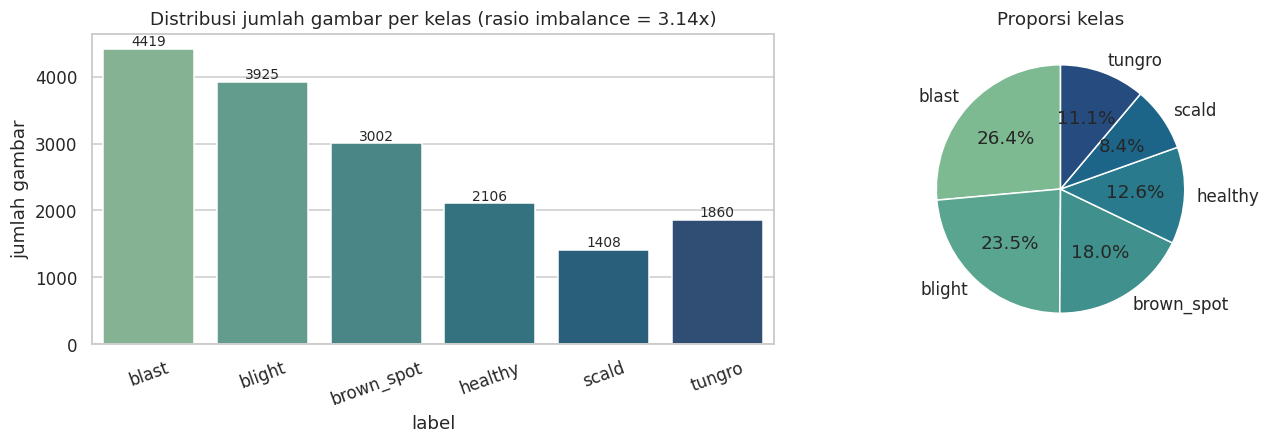

label
blast         4419
blight        3925
brown_spot    3002
healthy       2106
scald         1408
tungro        1860

Kelas mayoritas: blast (4419) | minoritas: scald (1408)
Rasio imbalance : 3.14x -> perlu penanganan khusus


In [9]:
# Distribusi kelas
counts = df["label"].value_counts().reindex(CLASSES).fillna(0).astype(int)
imbalance_ratio = counts.max() / max(counts.min(), 1)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
sns.barplot(x=counts.index, y=counts.values, ax=ax[0], palette="crest")
for i, v in enumerate(counts.values):
    ax[0].text(i, v, str(v), ha="center", va="bottom", fontsize=9)
ax[0].set_title(f"Distribusi jumlah gambar per kelas (rasio imbalance = {imbalance_ratio:.2f}x)")
ax[0].set_ylabel("jumlah gambar"); ax[0].tick_params(axis="x", rotation=20)

ax[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%", startangle=90,
          colors=sns.color_palette("crest", len(counts)))
ax[1].set_title("Proporsi kelas")
plt.tight_layout(); plt.savefig(OUT / "reports/figures/01_class_distribution.png", bbox_inches="tight"); plt.show()

print(counts.to_string())
print(f"\nKelas mayoritas: {counts.idxmax()} ({counts.max()}) | minoritas: {counts.idxmin()} ({counts.min()})")
print(f"Rasio imbalance : {imbalance_ratio:.2f}x -> {'perlu penanganan khusus' if imbalance_ratio > 1.5 else 'relatif seimbang'}")

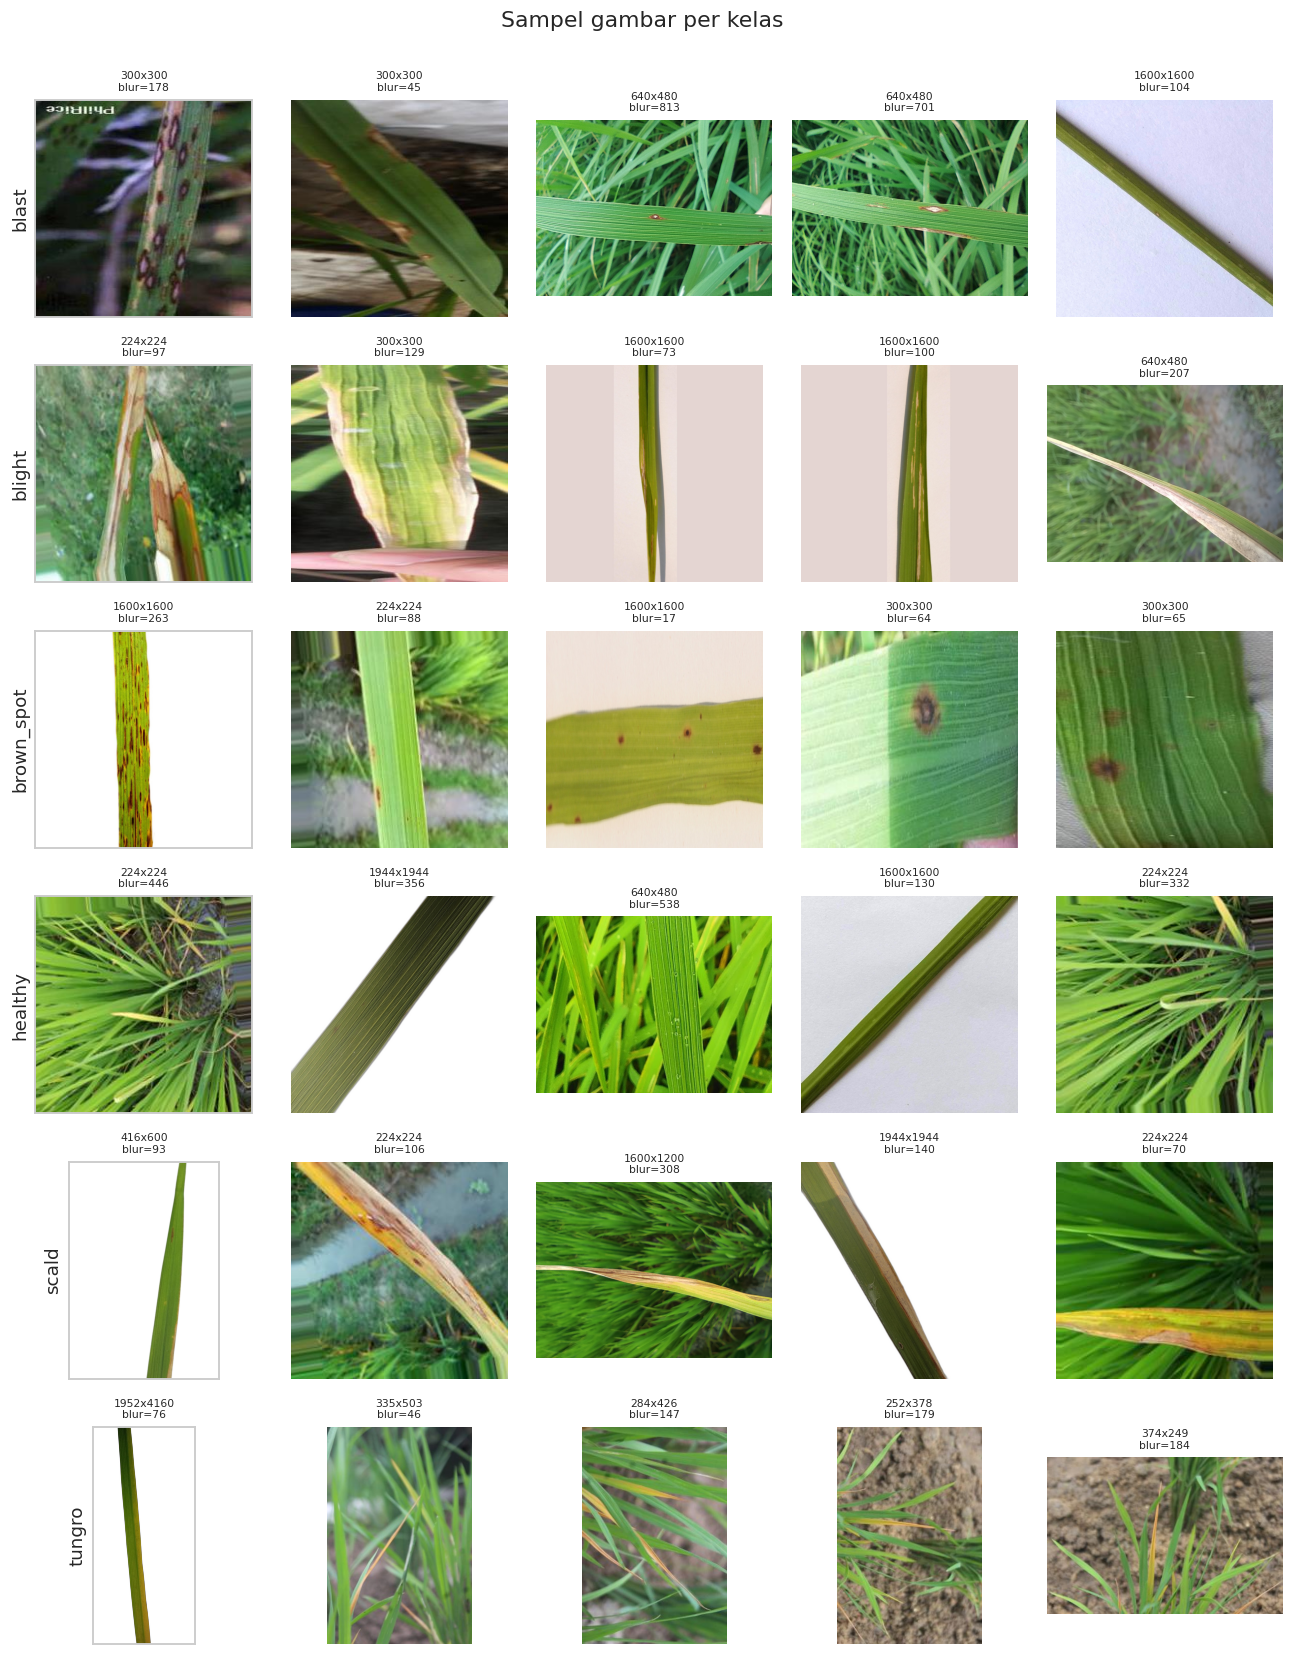

In [10]:
n_per_class = 5
fig, axes = plt.subplots(NUM_CLASSES, n_per_class, figsize=(n_per_class * 2.4, NUM_CLASSES * 2.5))
for r, cls in enumerate(CLASSES):
    sub = df[df["label"] == cls].sample(min(n_per_class, (df["label"] == cls).sum()),
                                        random_state=CONFIG["SEED"])
    for c in range(n_per_class):
        a = axes[r, c]; a.axis("off")
        if c < len(sub):
            row = sub.iloc[c]
            a.imshow(Image.open(row["path"]).convert("RGB"))
            a.set_title(f"{row['width']}x{row['height']}\nblur={row['blur']:.0f}", fontsize=7)
    axes[r, 0].set_ylabel(cls)
    axes[r, 0].axis("on"); axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])
plt.suptitle("Sampel gambar per kelas", y=1.002)
plt.tight_layout(); plt.savefig(OUT / "reports/figures/02_samples_per_class.png", bbox_inches="tight"); plt.show()

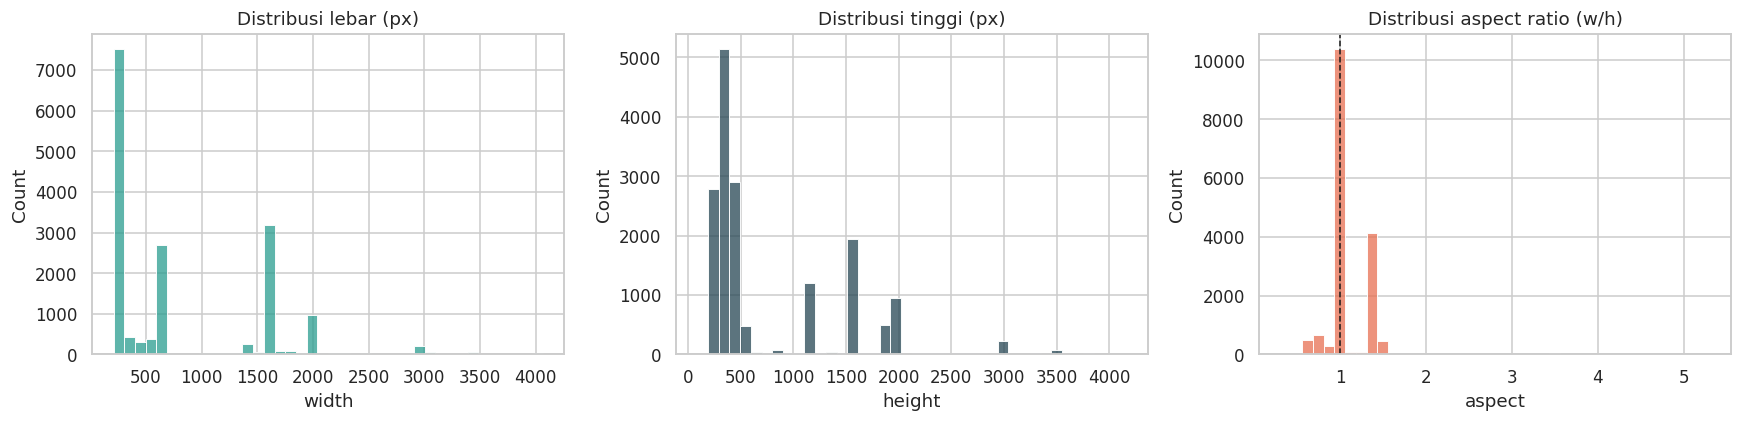

          width    height    aspect
count  16720.00  16720.00  16720.00
mean     829.87    780.24      1.09
std      720.03    707.87      0.25
min      209.00     88.00      0.31
25%      300.00    300.00      1.00
50%      500.00    480.00      1.00
75%     1600.00   1200.00      1.33
max     4064.00   4160.00      5.30

Ukuran paling umum:
 300x300      4624
640x480      2679
224x224      2384
1600x1600    1924
1600x1200    1175
1944x1944     904
500x500       190
1440x1920     184

Gambar di bawah 224px (akan ter-upscale, berpotensi blur): 238
Mode warna: {'RGB': 16245, 'RGBA': 475}


In [11]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df["width"], bins=40, ax=ax[0], color="#2a9d8f"); ax[0].set_title("Distribusi lebar (px)")
sns.histplot(df["height"], bins=40, ax=ax[1], color="#264653"); ax[1].set_title("Distribusi tinggi (px)")
sns.histplot(df["aspect"], bins=40, ax=ax[2], color="#e76f51"); ax[2].set_title("Distribusi aspect ratio (w/h)")
ax[2].axvline(1.0, ls="--", c="k", lw=1)
plt.tight_layout(); plt.savefig(OUT / "reports/figures/03_resolution.png", bbox_inches="tight"); plt.show()

print(df[["width", "height", "aspect"]].describe().round(2).to_string())
print("\nUkuran paling umum:\n",
      (df["width"].astype(str) + "x" + df["height"].astype(str)).value_counts().head(8).to_string())
print("\nGambar di bawah 224px (akan ter-upscale, berpotensi blur):",
      int(((df["width"] < 224) | (df["height"] < 224)).sum()))
print("Mode warna:", df["mode"].value_counts().to_dict())

In [12]:
# Deteksi duplikat dan near duplicate dengan perceptual hashing
# Hitung jarak Hamming antar pHash secara vektorisasi
# Jarak 0, duplikat identik/near-identik  (dibuang, sisakan 1)
# Jarak, near-duplicate (mis. hasil augmentasi/crop dari foto yang sama)
# Near duplicate tidak selalu dibuang, tapi wajib masuk split yang sama agar tidak leakage

POPCOUNT = np.array([bin(i).count("1") for i in range(256)], dtype=np.uint8)

def hamming_pairs(hashes: np.ndarray, threshold: int, chunk: int = 512):
    n = len(hashes)
    H = hashes.astype(np.uint64).view(np.uint8).reshape(n, 8)
    pairs = []
    for start in tqdm(range(0, n, chunk), desc="Hamming distance"):
        end = min(start + chunk, n)
        block = POPCOUNT[np.bitwise_xor(H[start:end, None, :], H[None, :, :])].sum(axis=-1)
        idx_i, idx_j = np.where(block <= threshold)
        for a, b in zip(idx_i, idx_j):
            i, j = start + int(a), int(b)
            if i < j:
                pairs.append((i, j, int(block[a, b])))
    return pairs


class UnionFind:
    def __init__(self, n): self.p = list(range(n))
    def find(self, x):
        while self.p[x] != x:
            self.p[x] = self.p[self.p[x]]; x = self.p[x]
        return x
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra != rb: self.p[rb] = ra


hashes = df["phash"].to_numpy(dtype=np.uint64)
if len(df) > 30000:
    print("[INFO] Dataset besar; perhitungan O(n^2) bisa lama. Pertimbangkan bucketing/LSH.")

pairs = hamming_pairs(hashes, CONFIG["PHASH_DUP_THRESHOLD"])
exact_pairs = [p for p in pairs if p[2] == 0]
near_pairs  = [p for p in pairs if p[2] > 0]

uf = UnionFind(len(df))
for i, j, _ in pairs:
    uf.union(i, j)
df["group_id"] = [uf.find(i) for i in range(len(df))]

grp_sizes = df["group_id"].value_counts()
print(f"Pasangan duplikat identik (dist=0) : {len(exact_pairs)}")
print(f"Pasangan near-duplicate (0<d<={CONFIG['PHASH_DUP_THRESHOLD']}) : {len(near_pairs)}")
print(f"Jumlah group unik                  : {df['group_id'].nunique()} (dari {len(df)} gambar)")
print(f"Group beranggota >1                : {(grp_sizes > 1).sum()}  | terbesar: {grp_sizes.max()} gambar")

cross = df.groupby("group_id")["label"].nunique()
cross_ids = cross[cross > 1].index.tolist()
print(f"\n[PENTING] Group yang berisi >1 kelas berbeda: {len(cross_ids)}")
if cross_ids:
    print("Contoh (gambar sangat mirip tapi labelnya beda -> perlu dicek manual):")
    display(df[df["group_id"].isin(cross_ids[:3])][["path", "label", "group_id"]])

Hamming distance:   0%|          | 0/33 [00:00<?, ?it/s]

Pasangan duplikat identik (dist=0) : 5749
Pasangan near-duplicate (0<d<=5) : 3230
Jumlah group unik                  : 11805 (dari 16720 gambar)
Group beranggota >1                : 2545  | terbesar: 39 gambar

[PENTING] Group yang berisi >1 kelas berbeda: 109
Contoh (gambar sangat mirip tapi labelnya beda -> perlu dicek manual):


,path,label,group_id
1483,/kaggle/input/datasets/rafidzakiazhari/citra-d...,blast,1483
1497,/kaggle/input/datasets/rafidzakiazhari/citra-d...,blast,1483
1514,/kaggle/input/datasets/rafidzakiazhari/citra-d...,blast,1514
1524,/kaggle/input/datasets/rafidzakiazhari/citra-d...,blast,1524
11389,/kaggle/input/datasets/rafidzakiazhari/citra-d...,healthy,1514
13625,/kaggle/input/datasets/rafidzakiazhari/citra-d...,scald,1524
14820,/kaggle/input/datasets/rafidzakiazhari/citra-d...,scald,1483
14826,/kaggle/input/datasets/rafidzakiazhari/citra-d...,scald,1483


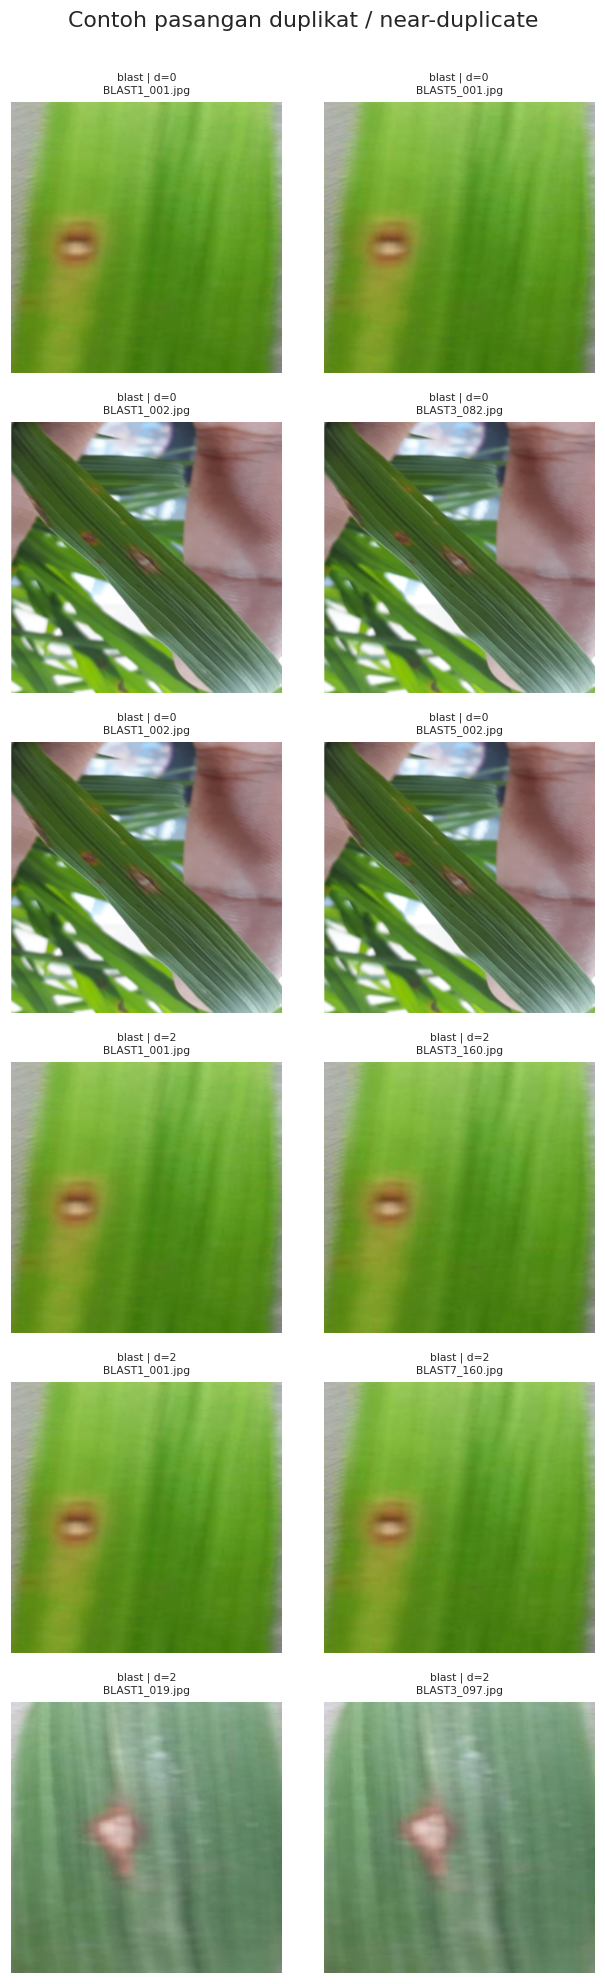

In [13]:
# Visualisasi contoh pasangan duplikat/near duplicate
show = (exact_pairs[:3] + near_pairs[:3])[:6]
if show:
    fig, axes = plt.subplots(len(show), 2, figsize=(6, 3 * len(show)))
    axes = np.atleast_2d(axes)
    for r, (i, j, d) in enumerate(show):
        for c, idx in enumerate([i, j]):
            axes[r, c].imshow(Image.open(df.iloc[idx]["path"]).convert("RGB")); axes[r, c].axis("off")
            axes[r, c].set_title(f"{df.iloc[idx]['label']} | d={d}\n{Path(df.iloc[idx]['path']).name[:26]}", fontsize=7)
    plt.suptitle("Contoh pasangan duplikat / near-duplicate", y=1.001)
    plt.tight_layout(); plt.savefig(OUT / "reports/figures/04_duplicates.png", bbox_inches="tight"); plt.show()
else:
    print("Tidak ditemukan pasangan duplikat pada threshold saat ini.")

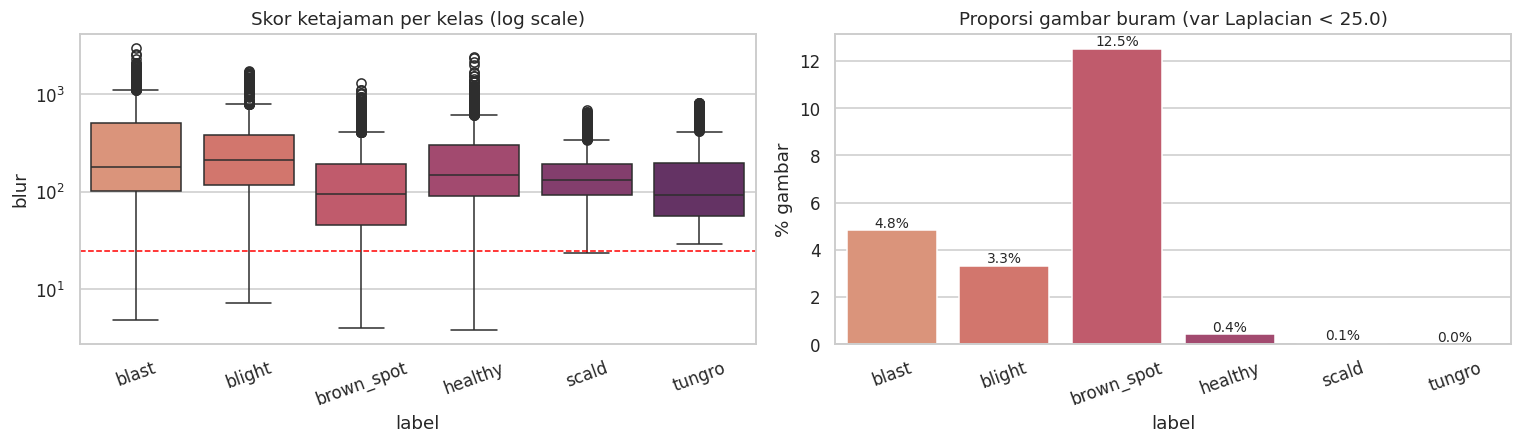

Gambar paling buram:


,path,label,blur,width,height
11977,/kaggle/input/datasets/rafidzakiazhari/citra-d...,healthy,3.823196,640,480
10889,/kaggle/input/datasets/rafidzakiazhari/citra-d...,brown_spot,4.038394,300,300
8544,/kaggle/input/datasets/rafidzakiazhari/citra-d...,brown_spot,4.075581,300,300
9144,/kaggle/input/datasets/rafidzakiazhari/citra-d...,brown_spot,4.075581,300,300
8445,/kaggle/input/datasets/rafidzakiazhari/citra-d...,brown_spot,4.089436,300,300


In [14]:
# Analisis kualitas gambar dengan Laplacian (semakin kecil semakin buram)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
sns.boxplot(data=df, x="label", y="blur", ax=ax[0], order=CLASSES, palette="flare")
ax[0].set_yscale("log"); ax[0].set_title("Skor ketajaman per kelas (log scale)")
ax[0].axhline(CONFIG["BLUR_THRESHOLD"], ls="--", c="red", lw=1)
ax[0].tick_params(axis="x", rotation=20)

blur_pct = df.assign(is_blur=df["blur"] < CONFIG["BLUR_THRESHOLD"]).groupby("label")["is_blur"].mean() * 100
blur_pct = blur_pct.reindex(CLASSES).fillna(0)
sns.barplot(x=blur_pct.index, y=blur_pct.values, ax=ax[1], palette="flare")
for i, v in enumerate(blur_pct.values):
    ax[1].text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
ax[1].set_title(f"Proporsi gambar buram (var Laplacian < {CONFIG['BLUR_THRESHOLD']})")
ax[1].set_ylabel("% gambar"); ax[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.savefig(OUT / "reports/figures/05_blur.png", bbox_inches="tight"); plt.show()

print("Gambar paling buram:")
display(df.nsmallest(5, "blur")[["path", "label", "blur", "width", "height"]])

In [15]:
# EDA
summary = {
    "total_gambar_valid": int(len(df)),
    "file_corrupt": int(len(corrupt)),
    "jumlah_kelas": int(df["label"].nunique()),
    "distribusi_kelas": counts.to_dict(),
    "rasio_imbalance": round(float(imbalance_ratio), 2),
    "resolusi_median": [int(df["width"].median()), int(df["height"].median())],
    "pasangan_duplikat_identik": len(exact_pairs),
    "pasangan_near_duplicate": len(near_pairs),
    "group_unik": int(df["group_id"].nunique()),
    "persen_gambar_buram": round(float((df["blur"] < CONFIG["BLUR_THRESHOLD"]).mean() * 100), 2),
    "group_lintas_kelas": len(cross_ids),
}
print(json.dumps(summary, indent=2))
json.dump(summary, open(OUT / "reports/eda_summary.json", "w"), indent=2)

{
  "total_gambar_valid": 16720,
  "file_corrupt": 0,
  "jumlah_kelas": 6,
  "distribusi_kelas": {
    "blast": 4419,
    "blight": 3925,
    "brown_spot": 3002,
    "healthy": 2106,
    "scald": 1408,
    "tungro": 1860
  },
  "rasio_imbalance": 3.14,
  "resolusi_median": [
    500,
    480
  ],
  "pasangan_duplikat_identik": 5749,
  "pasangan_near_duplicate": 3230,
  "group_unik": 11805,
  "persen_gambar_buram": 4.36,
  "group_lintas_kelas": 109
}


## 3. Data Cleaning, Split, dan Preprocessing

In [16]:
n_before = len(df)

# Buang duplikat identik: sisakan representatif terbaik per exact hash
df["_rank"] = df["blur"] * 1e-6 + df["width"] * df["height"]
df = (df.sort_values("_rank", ascending=False)
        .drop_duplicates(subset=["phash", "label"], keep="first")
        .drop(columns="_rank")
        .reset_index(drop=True))
print(f"Duplikat identik dibuang : {n_before - len(df)}  -> tersisa {len(df)}")

# Opsional buang near duplicate
if CONFIG["DROP_NEAR_DUP"]:
    n0 = len(df)
    df = df.sort_values("blur", ascending=False).drop_duplicates(subset=["group_id"], keep="first").reset_index(drop=True)
    print(f"Near-duplicate dibuang   : {n0 - len(df)}")

# Opsional buang gambar buram
if CONFIG["DROP_BLUR"]:
    n0 = len(df)
    df = df[df["blur"] >= CONFIG["BLUR_THRESHOLD"]].reset_index(drop=True)
    print(f"Gambar sangat buram dibuang: {n0 - len(df)}")

print("\nDistribusi kelas setelah cleaning:")
print(df["label"].value_counts().reindex(CLASSES).fillna(0).astype(int).to_string())

Duplikat identik dibuang : 3533  -> tersisa 13187

Distribusi kelas setelah cleaning:
label
blast         3440
blight        2849
brown_spot    2092
healthy       1951
scald         1360
tungro        1495


Group yang tersebar di >1 split : 0
Verifikasi anti-leakage: LOLOS



split,train,val,test,total
label,,,,
blast,2419,504,517,3440
blight,1993,428,428,2849
brown_spot,1464,314,314,2092
healthy,1377,285,289,1951
scald,961,201,198,1360
tungro,1048,223,224,1495



Proporsi aktual: {'train': 0.702, 'test': 0.149, 'val': 0.148}


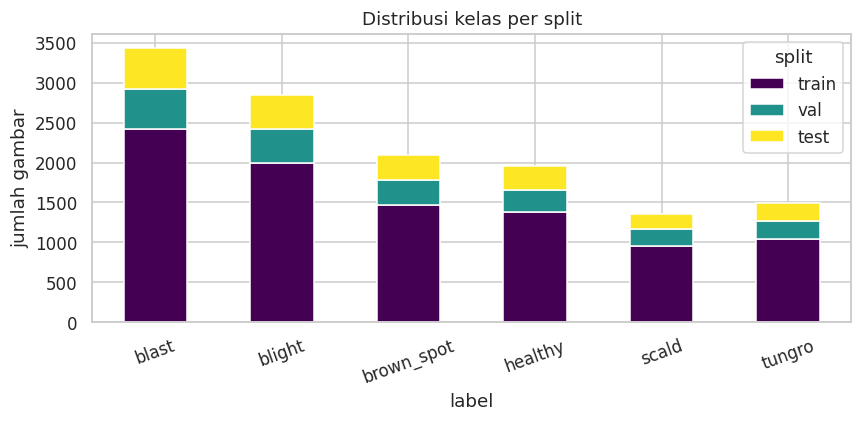

Manifest disimpan -> /kaggle/working/artifacts/reports/dataset_manifest.csv


In [17]:
# Group-aware stratified split agar tidak leakage, setiap group ditugaskan utuh ke satu split alokasi dilakukan, per kelas secara greedy agar proporsi kelas tetap terjaga

def group_stratified_split(frame: pd.DataFrame, ratios=(0.7, 0.15, 0.15), seed=42):
    rng = np.random.RandomState(seed)
    assignment = {}
    for cls in frame["label"].unique():
        sub = frame[frame["label"] == cls]
        groups = sub.groupby("group_id").size().sort_values(ascending=False)
        gids = list(groups.index)
        rng.shuffle(gids)
        gids = sorted(gids, key=lambda g: -groups[g])
        target = np.array(ratios) * len(sub)
        current = np.zeros(3)
        for g in gids:
            size = groups[g]
            deficit = (target - current) / np.maximum(target, 1)
            s = int(np.argmax(deficit))
            current[s] += size
            assignment[g] = ["train", "val", "test"][s]
    return frame["group_id"].map(assignment)


df["split"] = group_stratified_split(df, CONFIG["SPLIT_RATIO"], CONFIG["SEED"])

# satu group tidak boleh muncul di >1 split, agar tidak leakage
leak = df.groupby("group_id")["split"].nunique()
n_leak = int((leak > 1).sum())
print(f"Group yang tersebar di >1 split : {n_leak}")
assert n_leak == 0, "LEAKAGE terdeteksi! Periksa fungsi split."
print("Verifikasi anti-leakage: LOLOS\n")

pivot = (pd.crosstab(df["label"], df["split"])
           .reindex(index=CLASSES, columns=["train", "val", "test"])
           .fillna(0).astype(int))
pivot["total"] = pivot.sum(axis=1)
display(pivot)
print("\nProporsi aktual:", (df["split"].value_counts(normalize=True).round(3)).to_dict())

fig, ax = plt.subplots(figsize=(8, 4))
pivot[["train", "val", "test"]].plot(kind="bar", stacked=True, ax=ax, colormap="viridis")
ax.set_title("Distribusi kelas per split"); ax.set_ylabel("jumlah gambar"); plt.xticks(rotation=20)
plt.tight_layout(); plt.savefig(OUT / "reports/figures/06_split_distribution.png", bbox_inches="tight"); plt.show()

# Manifest disimpan
df.to_csv(OUT / "reports/dataset_manifest.csv", index=False)
print("Manifest disimpan ->", OUT / "reports/dataset_manifest.csv")

In [18]:
IMG = CONFIG["IMG_SIZE"]

train_tf = T.Compose([
    T.RandomResizedCrop(IMG, scale=(0.6, 1.0), ratio=(0.75, 1.333)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.2),
    T.RandomApply([T.RandomRotation(25)], p=0.5),
    T.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.20, hue=0.03),
    T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5))], p=0.2),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
    T.RandomErasing(p=0.15, scale=(0.02, 0.12)),
])

eval_tf = T.Compose([
    T.Resize(int(IMG * 1.15)),
    T.CenterCrop(IMG),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])


class RiceLeafDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, transform=None, classes=CLASSES):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform
        self.classes = classes
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.targets = [self.class_to_idx[l] for l in self.frame["label"]]

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, i):
        row = self.frame.iloc[i]
        try:
            img = Image.open(row["path"]).convert("RGB")
        except Exception:
            img = Image.new("RGB", (IMG, IMG), (0, 0, 0))
        if self.transform:
            img = self.transform(img)
        return img, self.targets[i], i


train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df   = df[df["split"] == "val"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)

train_ds = RiceLeafDataset(train_df, train_tf)
val_ds   = RiceLeafDataset(val_df,   eval_tf)
test_ds  = RiceLeafDataset(test_df,  eval_tf)

# WeightedRandomSampler
train_counts = np.bincount(train_ds.targets, minlength=NUM_CLASSES).astype(float)
class_weights = 1.0 / np.maximum(train_counts, 1)
sample_weights = class_weights[train_ds.targets]
sampler = WeightedRandomSampler(torch.DoubleTensor(sample_weights), num_samples=len(train_ds), replacement=True) \
          if CONFIG["USE_SAMPLER"] else None

common = dict(num_workers=CONFIG["NUM_WORKERS"], pin_memory=(DEVICE.type == "cuda"), persistent_workers=CONFIG["NUM_WORKERS"] > 0)
train_loader = DataLoader(train_ds, batch_size=CONFIG["BATCH_SIZE"], sampler=sampler, shuffle=(sampler is None), drop_last=True, **common)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG["BATCH_SIZE"] * 2, shuffle=False, **common)
test_loader  = DataLoader(test_ds,  batch_size=CONFIG["BATCH_SIZE"] * 2, shuffle=False, **common)

print(f"train: {len(train_ds)} | val: {len(val_ds)} | test: {len(test_ds)}")
print("Jumlah per kelas (train):", dict(zip(CLASSES, train_counts.astype(int))))
print("Sampler aktif:", sampler is not None)

train: 9262 | val: 1955 | test: 1970
Jumlah per kelas (train): {'blast': np.int64(2419), 'blight': np.int64(1993), 'brown_spot': np.int64(1464), 'healthy': np.int64(1377), 'scald': np.int64(961), 'tungro': np.int64(1048)}
Sampler aktif: True


Bentuk batch: torch.Size([32, 3, 224, 224]) | range nilai: -2.12 s/d 2.64


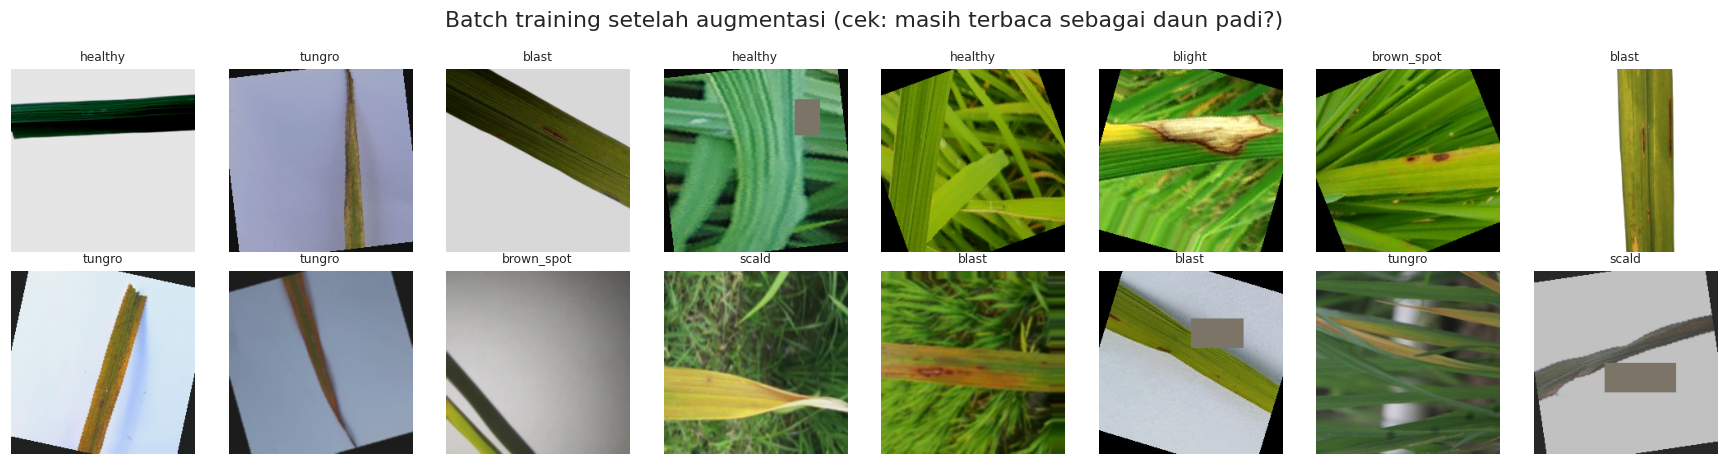

Distribusi kelas pada 10 batch pertama: {'blast': 58, 'blight': 59, 'brown_spot': 54, 'healthy': 38, 'scald': 54, 'tungro': 57}


In [19]:
# test lihat satu batch training setelah augmentasi
xb, yb, _ = next(iter(train_loader))
print("Bentuk batch:", xb.shape, "| range nilai:", round(xb.min().item(), 2), "s/d", round(xb.max().item(), 2))

inv = lambda t: (t * torch.tensor(STD)[:, None, None] + torch.tensor(MEAN)[:, None, None]).clamp(0, 1)
fig, axes = plt.subplots(2, 8, figsize=(16, 4.3))
for i, a in enumerate(axes.flat):
    if i < len(xb):
        a.imshow(inv(xb[i]).permute(1, 2, 0).numpy()); a.set_title(CLASSES[yb[i]], fontsize=8)
    a.axis("off")
plt.suptitle("Batch training setelah augmentasi (cek: masih terbaca sebagai daun padi?)")
plt.tight_layout(); plt.savefig(OUT / "reports/figures/07_augmented_batch.png", bbox_inches="tight"); plt.show()

# Distribusi kelas dalam beberapa batch membuktikan sampler bekerja
sample_labels = []
for k, (_, y, _) in enumerate(train_loader):
    sample_labels += y.tolist()
    if k >= 9: break
print("Distribusi kelas pada 10 batch pertama:",
      {CLASSES[i]: c for i, c in sorted(Counter(sample_labels).items())})

## 4. Modeling Pemilihan Model Pre Train

In [20]:
def build_model(name=None, num_classes=NUM_CLASSES, pretrained=True):
    name = name or CONFIG["MODEL_NAME"]
    m = timm.create_model(name, pretrained=pretrained, num_classes=num_classes, drop_path_rate=CONFIG["DROP_PATH"])
    return m

model = build_model().to(DEVICE)

# Verifikasi mean/std yang dipakai bobot pretrained
cfg = timm.data.resolve_data_config({}, model=model)
print("Config pretrained timm:", {k: cfg[k] for k in ["input_size", "mean", "std", "crop_pct"] if k in cfg})
if list(cfg["mean"]) != MEAN or list(cfg["std"]) != STD:
    print("[PERHATIAN] mean/std berbeda dari asumsi. Menyesuaikan otomatis.")
    MEAN, STD = list(cfg["mean"]), list(cfg["std"])

n_total = sum(p.numel() for p in model.parameters())
print(f"\nModel      : {CONFIG['MODEL_NAME']}")
print(f"Parameter  : {n_total/1e6:.2f} M  (~{n_total*4/1e6:.0f} MB fp32)")
print("Head       :", model.default_cfg.get("classifier", "head.fc"))

with torch.no_grad():
    out = model(torch.randn(2, 3, IMG, IMG).to(DEVICE))
print("Output shape (sanity check):", tuple(out.shape))

model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

Config pretrained timm: {'input_size': (3, 224, 224), 'mean': (0.485, 0.456, 0.406), 'std': (0.229, 0.224, 0.225), 'crop_pct': 0.875}

Model      : convnextv2_tiny.fcmae_ft_in22k_in1k
Parameter  : 27.87 M  (~111 MB fp32)
Head       : head.fc
Output shape (sanity check): (2, 6)


In [21]:
# Loss, optimizer, scheduler
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None, label_smoothing=0.0):
        super().__init__()
        self.gamma, self.weight, self.ls = gamma, weight, label_smoothing
    def forward(self, logits, target):
        ce = F.cross_entropy(logits, target, weight=self.weight,
                             label_smoothing=self.ls, reduction="none")
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

# Bobot kelas (dipakai hanya bila USE_CLASS_WEIGHTS=True)
w = torch.tensor(len(train_ds) / (NUM_CLASSES * np.maximum(train_counts, 1)),
                 dtype=torch.float32, device=DEVICE)
loss_weight = w if CONFIG["USE_CLASS_WEIGHTS"] else None
if CONFIG["USE_SAMPLER"] and CONFIG["USE_CLASS_WEIGHTS"]:
    print("[PERHATIAN] Sampler + class weights aktif bersamaan = over-correction. Pilih salah satu.")

criterion = (FocalLoss(gamma=2.0, weight=loss_weight, label_smoothing=CONFIG["LABEL_SMOOTHING"])
             if CONFIG["USE_FOCAL"] else
             nn.CrossEntropyLoss(weight=loss_weight, label_smoothing=CONFIG["LABEL_SMOOTHING"]))
print("Loss:", criterion.__class__.__name__, "| class weights:", "ya" if loss_weight is not None else "tidak")


def head_param_names(model):
    clf = model.default_cfg.get("classifier", "head.fc")
    prefix = clf.split(".")[0]
    return [n for n, _ in model.named_parameters() if n.startswith(prefix)]

HEAD_NAMES = set(head_param_names(model))

def set_backbone_trainable(model, flag: bool):
    for n, p in model.named_parameters():
        if n not in HEAD_NAMES:
            p.requires_grad = flag

def trainable_report(model):
    tr = sum(p.numel() for p in model.parameters() if p.requires_grad)
    tot = sum(p.numel() for p in model.parameters())
    return f"{tr/1e6:.2f}M / {tot/1e6:.2f}M parameter dilatih ({tr/tot*100:.1f}%)"

print("Parameter head:", len(HEAD_NAMES), "tensor")

Loss: CrossEntropyLoss | class weights: tidak
Parameter head: 4 tensor


In [22]:
# Train / evaluasi satu epoch
def run_epoch(model, loader, criterion, optimizer=None, scheduler=None, scaler=None, train=True, accum=1, desc=""):
    model.train(train)
    total_loss, n = 0.0, 0
    ys, ps = [], []
    ctx = contextlib.nullcontext() if train else torch.no_grad()
    with ctx:
        for step, (x, y, _) in enumerate(tqdm(loader, desc=desc, leave=False)):
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            with autocast_ctx():
                logits = model(x)
                loss = criterion(logits, y)
            if train:
                scaler.scale(loss / accum).backward()
                if (step + 1) % accum == 0:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad(set_to_none=True)
                    if scheduler is not None:
                        scheduler.step()
            bs = y.size(0)
            total_loss += loss.item() * bs
            n += bs
            ys.append(y.detach().cpu().numpy())
            ps.append(logits.detach().float().argmax(1).cpu().numpy())
    ys, ps = np.concatenate(ys), np.concatenate(ps)
    return {"loss": total_loss / max(n, 1),
            "acc": accuracy_score(ys, ps),
            "f1": f1_score(ys, ps, average="macro", zero_division=0)}


@torch.no_grad()
def predict_probs(model, loader, tta_hflip=False):
    model.eval()
    P, Y, IDX = [], [], []
    for x, y, idx in tqdm(loader, desc="Inference", leave=False):
        x = x.to(DEVICE, non_blocking=True)
        with autocast_ctx():
            p = torch.softmax(model(x).float(), 1)
            if tta_hflip:
                p = (p + torch.softmax(model(torch.flip(x, dims=[3])).float(), 1)) / 2
        P.append(p.cpu().numpy()); Y.append(y.numpy()); IDX.append(idx.numpy())
    return np.concatenate(P), np.concatenate(Y), np.concatenate(IDX)


history = {"epoch": [], "phase": [], "train_loss": [], "train_acc": [], "train_f1": [],
           "val_loss": [], "val_acc": [], "val_f1": [], "lr": []}

def log_epoch(ep, phase, tr, va, lr):
    history["epoch"].append(ep); history["phase"].append(phase); history["lr"].append(lr)
    for k in ["loss", "acc", "f1"]:
        history[f"train_{k}"].append(tr[k]); history[f"val_{k}"].append(va[k])
    print(f"[{phase}] ep {ep:02d} | train loss {tr['loss']:.4f} acc {tr['acc']:.4f} f1 {tr['f1']:.4f} "
          f"|| val loss {va['loss']:.4f} acc {va['acc']:.4f} f1 {va['f1']:.4f} | lr {lr:.2e}")

In [23]:
# Fase 1 head (backbone dibekukan)
CKPT = OUT / "checkpoints/best_model.pth"

set_backbone_trainable(model, False)
print("Fase 1:", trainable_report(model))

opt1 = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=CONFIG["LR_HEAD"], weight_decay=CONFIG["WEIGHT_DECAY"])
sched1 = torch.optim.lr_scheduler.CosineAnnealingLR(opt1, T_max=max(CONFIG["EPOCHS_HEAD"], 1) * len(train_loader))
scaler = make_scaler()

t_start = time.time()
for ep in range(1, CONFIG["EPOCHS_HEAD"] + 1):
    tr = run_epoch(model, train_loader, criterion, opt1, sched1, scaler, train=True, accum=CONFIG["GRAD_ACCUM"], desc=f"P1 train ep{ep}")
    va = run_epoch(model, val_loader, criterion, train=False, desc=f"P1 val ep{ep}")
    log_epoch(ep, "head", tr, va, opt1.param_groups[0]["lr"])
print(f"Fase 1 selesai dalam {(time.time()-t_start)/60:.1f} menit")

Fase 1: 0.01M / 27.87M parameter dilatih (0.0%)


P1 train ep1:   0%|          | 0/289 [00:00<?, ?it/s]

P1 val ep1:   0%|          | 0/31 [00:00<?, ?it/s]

[head] ep 01 | train loss 0.8862 acc 0.7299 f1 0.7286 || val loss 0.6821 acc 0.8205 f1 0.8261 | lr 7.50e-04


P1 train ep2:   0%|          | 0/289 [00:00<?, ?it/s]

P1 val ep2:   0%|          | 0/31 [00:00<?, ?it/s]

[head] ep 02 | train loss 0.6835 acc 0.8244 f1 0.8242 || val loss 0.5960 acc 0.8542 f1 0.8551 | lr 2.50e-04


P1 train ep3:   0%|          | 0/289 [00:00<?, ?it/s]

P1 val ep3:   0%|          | 0/31 [00:00<?, ?it/s]

[head] ep 03 | train loss 0.6671 acc 0.8335 f1 0.8326 || val loss 0.5870 acc 0.8634 f1 0.8630 | lr 0.00e+00
Fase 1 selesai dalam 7.3 menit


In [24]:
# Fase 2 Fine tune penuh + discriminative LR + OneCycleLR + early stopping + checkpoint terbaik dari macro f1
set_backbone_trainable(model, True)
print("Fase 2:", trainable_report(model))

backbone_params = [p for n, p in model.named_parameters() if n not in HEAD_NAMES]
head_params     = [p for n, p in model.named_parameters() if n in HEAD_NAMES]

opt2 = torch.optim.AdamW(
    [{"params": backbone_params, "lr": CONFIG["LR_BACKBONE"]},
     {"params": head_params,     "lr": CONFIG["LR_HEAD"]}],
    weight_decay=CONFIG["WEIGHT_DECAY"])

steps_per_epoch = max(len(train_loader) // CONFIG["GRAD_ACCUM"], 1)
sched2 = torch.optim.lr_scheduler.OneCycleLR(
    opt2, max_lr=[CONFIG["LR_BACKBONE"], CONFIG["LR_HEAD"]],
    steps_per_epoch=steps_per_epoch, epochs=CONFIG["EPOCHS_FULL"],
    pct_start=0.1, div_factor=10, final_div_factor=100)

best_f1, best_epoch, patience = -1.0, -1, 0
t_start = time.time()

for ep in range(1, CONFIG["EPOCHS_FULL"] + 1):
    tr = run_epoch(model, train_loader, criterion, opt2, sched2, scaler, train=True,
                   accum=CONFIG["GRAD_ACCUM"], desc=f"P2 train ep{ep}")
    va = run_epoch(model, val_loader, criterion, train=False, desc=f"P2 val ep{ep}")
    log_epoch(CONFIG["EPOCHS_HEAD"] + ep, "full", tr, va, opt2.param_groups[0]["lr"])

    if va["f1"] > best_f1:
        best_f1, best_epoch, patience = va["f1"], ep, 0
        torch.save({"state_dict": model.state_dict(),
                    "model_name": CONFIG["MODEL_NAME"],
                    "classes": CLASSES, "img_size": IMG, "mean": MEAN, "std": STD,
                    "val_f1": best_f1, "val_acc": va["acc"], "epoch": ep,
                    "config": CONFIG}, CKPT)
        print(f"   -> checkpoint disimpan (val macro-F1 {best_f1:.4f})")
    else:
        patience += 1
        if patience >= CONFIG["PATIENCE"]:
            print(f"Early stopping di epoch {ep} (tidak ada perbaikan {CONFIG['PATIENCE']} epoch)")
            break

print(f"\nFase 2 selesai dalam {(time.time()-t_start)/60:.1f} menit")
print(f"Val macro-F1 terbaik: {best_f1:.4f} (epoch {best_epoch})")
pd.DataFrame(history).to_csv(OUT / "reports/training_history.csv", index=False)

Fase 2: 27.87M / 27.87M parameter dilatih (100.0%)


P2 train ep1:   0%|          | 0/289 [00:00<?, ?it/s]

P2 val ep1:   0%|          | 0/31 [00:00<?, ?it/s]

[full] ep 04 | train loss 0.5763 acc 0.8744 f1 0.8742 || val loss 0.5003 acc 0.9125 f1 0.9085 | lr 6.30e-05
   -> checkpoint disimpan (val macro-F1 0.9085)


P2 train ep2:   0%|          | 0/289 [00:00<?, ?it/s]

...

P2 val ep17:   0%|          | 0/31 [00:00<?, ?it/s]

[full] ep 20 | train loss 0.2787 acc 0.9851 f1 0.9851 || val loss 0.3072 acc 0.9749 f1 0.9727 | lr 1.03e-06


P2 train ep18:   0%|          | 0/289 [00:00<?, ?it/s]

P2 val ep18:   0%|          | 0/31 [00:00<?, ?it/s]

[full] ep 21 | train loss 0.2706 acc 0.9892 f1 0.9892 || val loss 0.3065 acc 0.9749 f1 0.9728 | lr 1.00e-07

Fase 2 selesai dalam 46.7 menit
Val macro-F1 terbaik: 0.9744 (epoch 15)


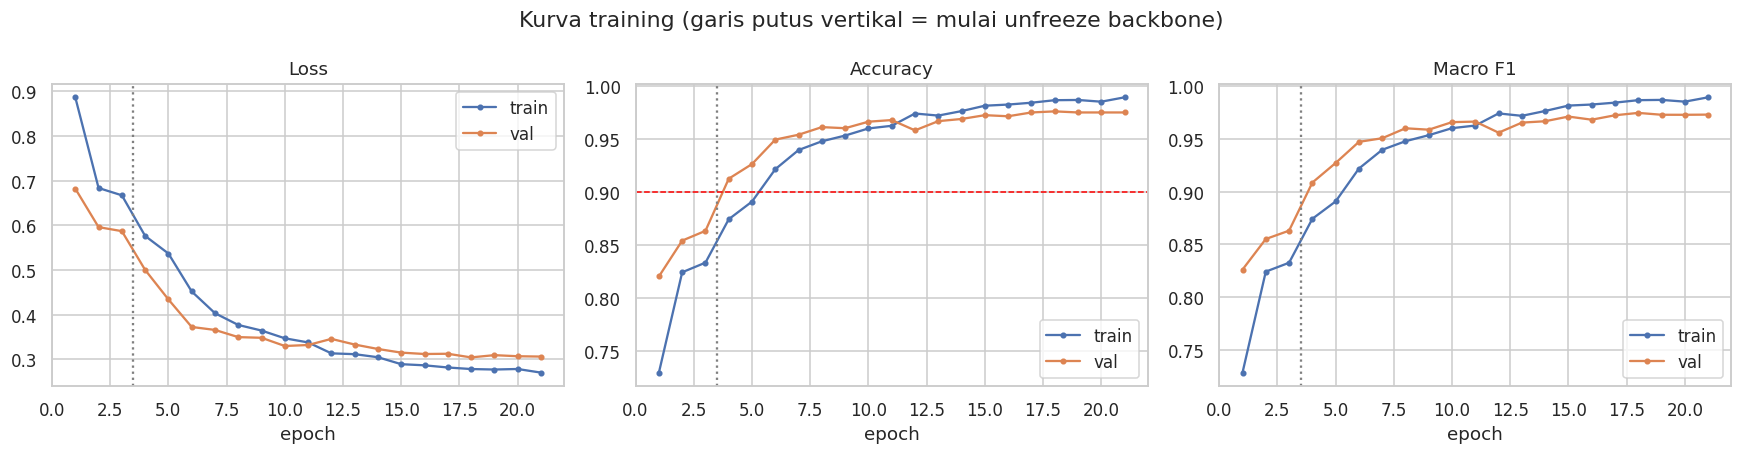

Gap train-val accuracy pada epoch terakhir: 0.014 -> wajar


In [25]:
# Kurva training/validation
h = pd.DataFrame(history)
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].plot(h["epoch"], h["train_loss"], "-o", ms=3, label="train")
ax[0].plot(h["epoch"], h["val_loss"], "-o", ms=3, label="val"); ax[0].set_title("Loss")
ax[1].plot(h["epoch"], h["train_acc"], "-o", ms=3, label="train")
ax[1].plot(h["epoch"], h["val_acc"], "-o", ms=3, label="val"); ax[1].set_title("Accuracy")
ax[2].plot(h["epoch"], h["train_f1"], "-o", ms=3, label="train")
ax[2].plot(h["epoch"], h["val_f1"], "-o", ms=3, label="val"); ax[2].set_title("Macro F1")
for a in ax:
    a.axvline(CONFIG["EPOCHS_HEAD"] + 0.5, ls=":", c="gray")
    a.set_xlabel("epoch"); a.legend()
ax[1].axhline(CONFIG["TARGET_ACC"], ls="--", c="red", lw=1)
plt.suptitle("Kurva training (garis putus vertikal = mulai unfreeze backbone)")
plt.tight_layout(); plt.savefig(OUT / "reports/figures/08_training_curves.png", bbox_inches="tight"); plt.show()

gap = h["train_acc"].iloc[-1] - h["val_acc"].iloc[-1]
print(f"Gap train-val accuracy pada epoch terakhir: {gap:.3f}",
      "-> indikasi overfitting, pertimbangkan augmentasi lebih kuat / drop_path lebih besar" if gap > 0.10 else "-> wajar")

## 5. Evaluasi

In [26]:
# Dari checkpoint terbaik
ckpt = torch.load(CKPT, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["state_dict"])
model.eval()
print(f"Checkpoint dimuat: epoch {ckpt['epoch']} | val macro-F1 {ckpt['val_f1']:.4f}")

probs, y_true, idxs = predict_probs(model, test_loader, tta_hflip=CONFIG["TTA_HFLIP"])
y_pred = probs.argmax(1)
conf   = probs.max(1)

metrics = {
    "accuracy":        float(accuracy_score(y_true, y_pred)),
    "macro_f1":        float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
    "macro_precision": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
    "macro_recall":    float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
    "weighted_f1":     float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
    "n_test":          int(len(y_true)),
    "tta_hflip":       bool(CONFIG["TTA_HFLIP"]),
}
print("\n=== HASIL TEST SET ===")
for k, v in metrics.items():
    print(f"{k:17s}: {v:.4f}" if isinstance(v, float) else f"{k:17s}: {v}")

target = CONFIG["TARGET_ACC"]
print(f"\nTarget >{target*100:.0f}% : accuracy {'TERCAPAI' if metrics['accuracy'] >= target else 'BELUM'} | "
      f"macro-F1 {'TERCAPAI' if metrics['macro_f1'] >= target else 'BELUM'}")

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4, zero_division=0))

rep = pd.DataFrame(classification_report(y_true, y_pred, target_names=CLASSES, output_dict=True, zero_division=0)).T
rep.to_csv(OUT / "reports/classification_report.csv")
json.dump(metrics, open(OUT / "reports/test_metrics.json", "w"), indent=2)

Checkpoint dimuat: epoch 15 | val macro-F1 0.9744


Inference:   0%|          | 0/31 [00:00<?, ?it/s]


=== HASIL TEST SET ===
accuracy         : 0.9655
macro_f1         : 0.9623
macro_precision  : 0.9615
macro_recall     : 0.9631
weighted_f1      : 0.9655
n_test           : 1970
tta_hflip        : True

Target >90% : accuracy TERCAPAI | macro-F1 TERCAPAI

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

       blast     0.9667    0.9555    0.9611       517
      blight     0.9930    0.9977    0.9953       428
  brown_spot     0.9747    0.9809    0.9778       314
     healthy     0.9377    0.9377    0.9377       289
       scald     0.9550    0.9646    0.9598       198
      tungro     0.9420    0.9420    0.9420       224

    accuracy                         0.9655      1970
   macro avg     0.9615    0.9631    0.9623      1970
weighted avg     0.9655    0.9655    0.9655      1970



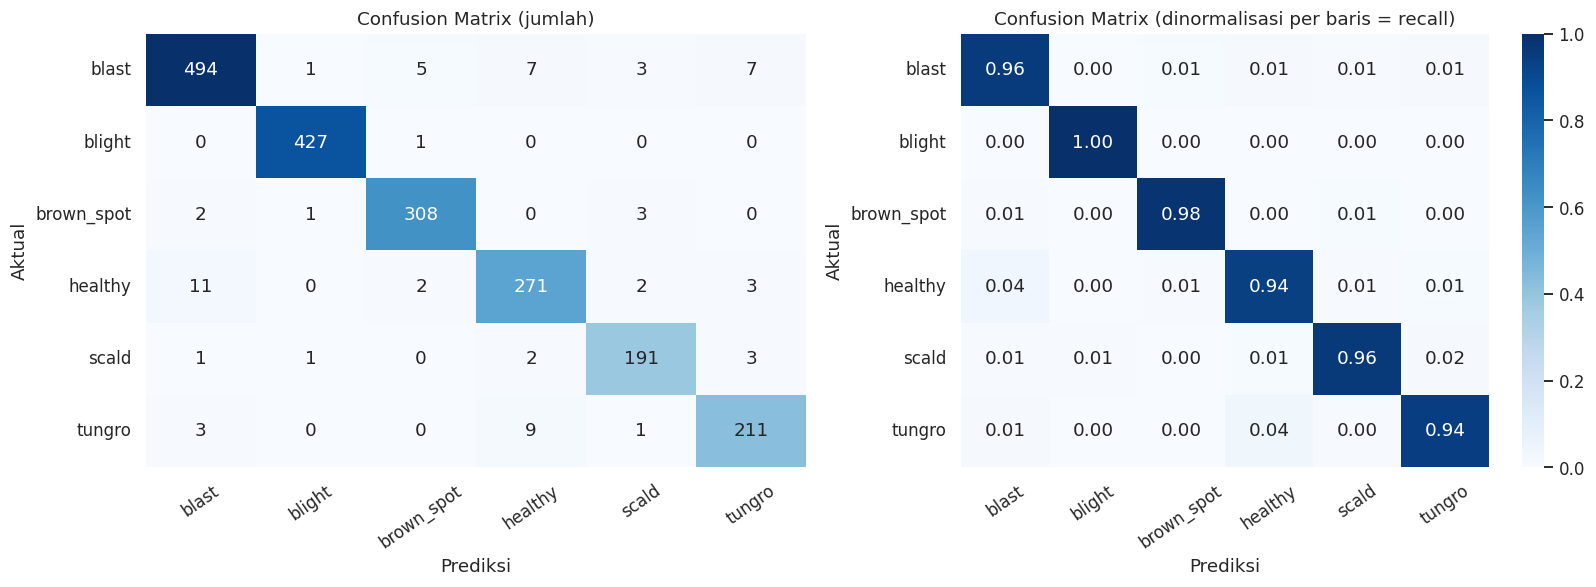

Recall per kelas: {'blast': 0.956, 'blight': 0.998, 'brown_spot': 0.981, 'healthy': 0.938, 'scald': 0.965, 'tungro': 0.942}


In [27]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=range(NUM_CLASSES))
cmn = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES, ax=ax[0], cbar=False)
ax[0].set_title("Confusion Matrix (jumlah)"); ax[0].set_xlabel("Prediksi"); ax[0].set_ylabel("Aktual")
sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES, ax=ax[1], vmin=0, vmax=1)
ax[1].set_title("Confusion Matrix (dinormalisasi per baris = recall)")
ax[1].set_xlabel("Prediksi"); ax[1].set_ylabel("Aktual")
for a in ax:
    a.tick_params(axis="x", rotation=35); a.tick_params(axis="y", rotation=0)
plt.tight_layout(); plt.savefig(OUT / "reports/figures/09_confusion_matrix.png", bbox_inches="tight"); plt.show()

print("Recall per kelas:", {CLASSES[i]: round(float(cmn[i, i]), 3) for i in range(NUM_CLASSES)})

In [28]:
# Analisis error: kelas mana yang tertukar
err_mask = y_pred != y_true
test_eval = test_df.iloc[idxs].reset_index(drop=True)
test_eval["y_true"]  = [CLASSES[i] for i in y_true]
test_eval["y_pred"]  = [CLASSES[i] for i in y_pred]
test_eval["conf"]    = conf
test_eval["correct"] = ~err_mask
test_eval.to_csv(OUT / "reports/test_predictions.csv", index=False)

print(f"Total salah klasifikasi: {int(err_mask.sum())} dari {len(y_true)} ({err_mask.mean()*100:.2f}%)\n")

pairs_err = Counter((CLASSES[t], CLASSES[p]) for t, p in zip(y_true[err_mask], y_pred[err_mask]))
print("Pasangan paling sering tertukar (aktual -> prediksi):")
for (t, p), c in pairs_err.most_common(8):
    print(f"  {t:11s} -> {p:11s} : {c}")

# Apakah error berkorelasi dengan kualitas gambar
print("\nPerbandingan karakteristik gambar benar vs salah:")
display(test_eval.groupby("correct")[["blur", "width", "height", "conf"]].agg(["mean", "median"]).round(2))
print("\nRata-rata confidence: benar = %.3f | salah = %.3f" %
      (test_eval[test_eval.correct]["conf"].mean(), test_eval[~test_eval.correct]["conf"].mean()))

Total salah klasifikasi: 68 dari 1970 (3.45%)

Pasangan paling sering tertukar (aktual -> prediksi):
  healthy     -> blast       : 11
  tungro      -> healthy     : 9
  blast       -> healthy     : 7
  blast       -> tungro      : 7
  blast       -> brown_spot  : 5
  blast       -> scald       : 3
  scald       -> tungro      : 3
  tungro      -> blast       : 3

Perbandingan karakteristik gambar benar vs salah:


blur            width           height          conf       
           mean  median     mean  median     mean  median  mean median
correct                                                               
False    188.10  120.45  1767.90  1944.0  1642.65  1649.5  0.78   0.82
True     255.21  150.45   907.98   640.0   854.55   480.0  0.95   0.96


Rata-rata confidence: benar = 0.953 | salah = 0.781


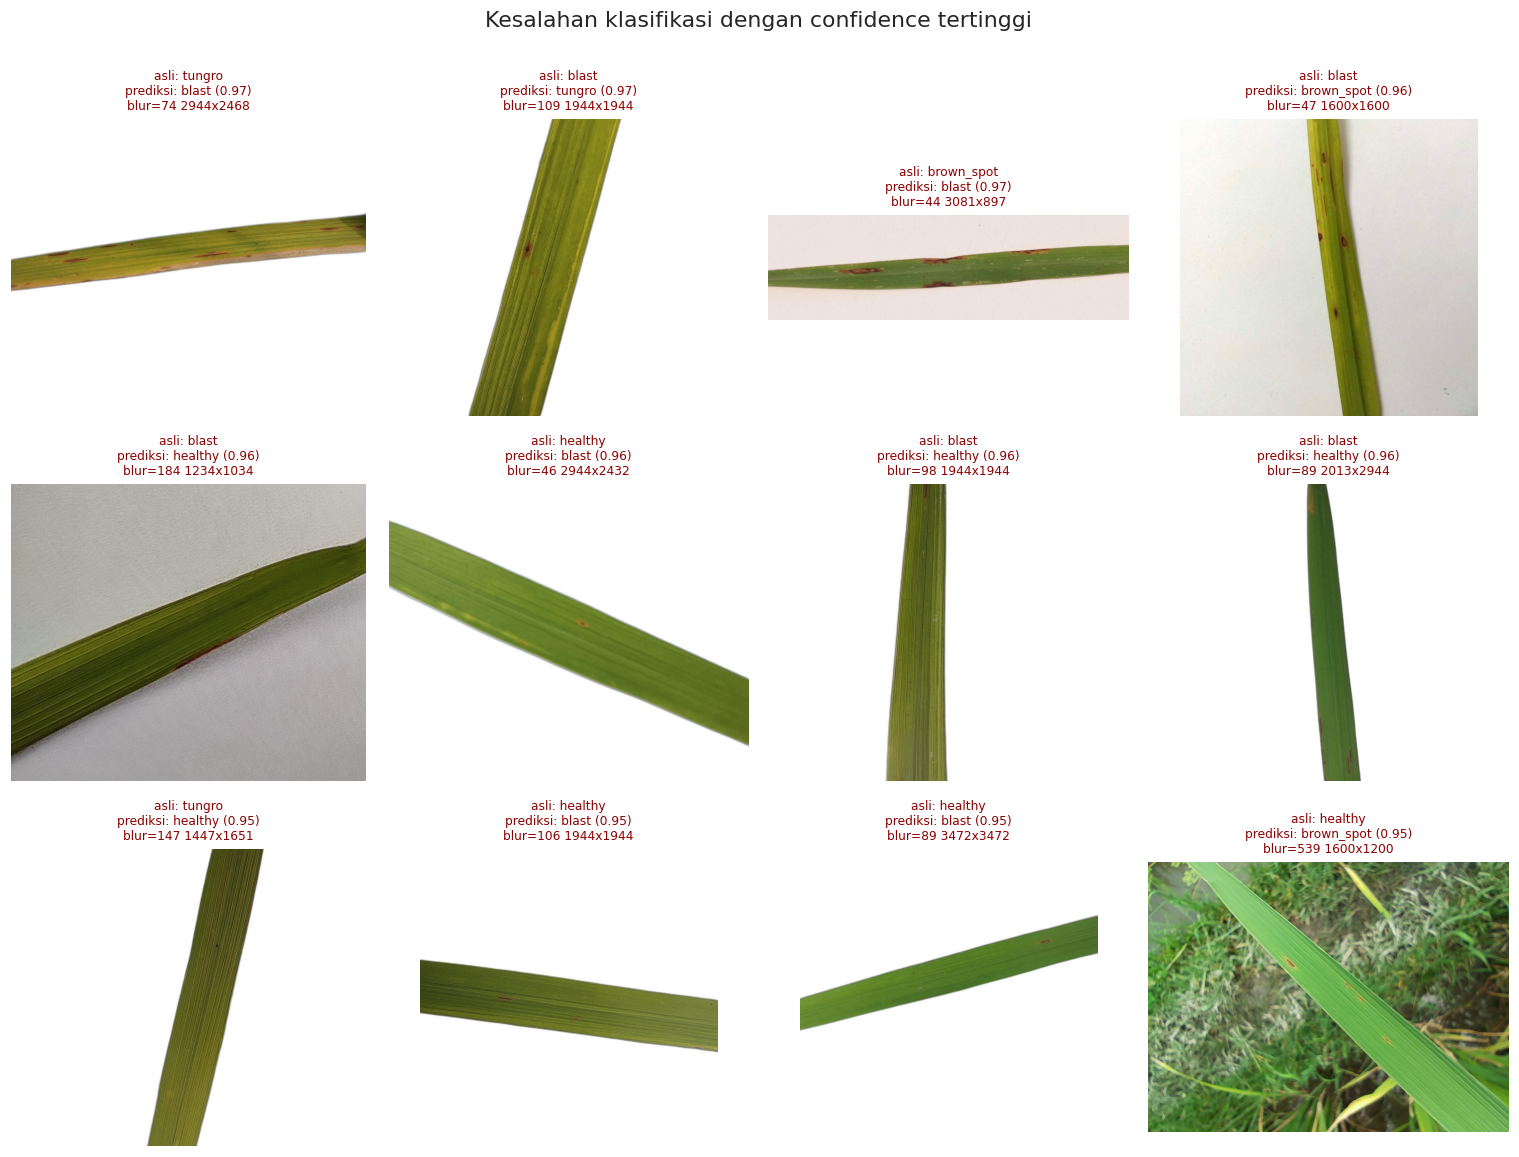

In [29]:
# Contoh gambar yang salah diklasifikasi
wrong = test_eval[~test_eval["correct"]].sort_values("conf", ascending=False)
n_show = min(12, len(wrong))
if n_show:
    fig, axes = plt.subplots(3, 4, figsize=(14, 10.5))
    for i, a in enumerate(axes.flat):
        a.axis("off")
        if i < n_show:
            r = wrong.iloc[i]
            a.imshow(Image.open(r["path"]).convert("RGB"))
            a.set_title(f"asli: {r['y_true']}\nprediksi: {r['y_pred']} ({r['conf']:.2f})\nblur={r['blur']:.0f} {r['width']}x{r['height']}",
                        fontsize=8, color="darkred")
    plt.suptitle("Kesalahan klasifikasi dengan confidence tertinggi", y=1.0)
    plt.tight_layout(); plt.savefig(OUT / "reports/figures/10_misclassified.png", bbox_inches="tight"); plt.show()
else:
    print("Tidak ada kesalahan klasifikasi pada test set")

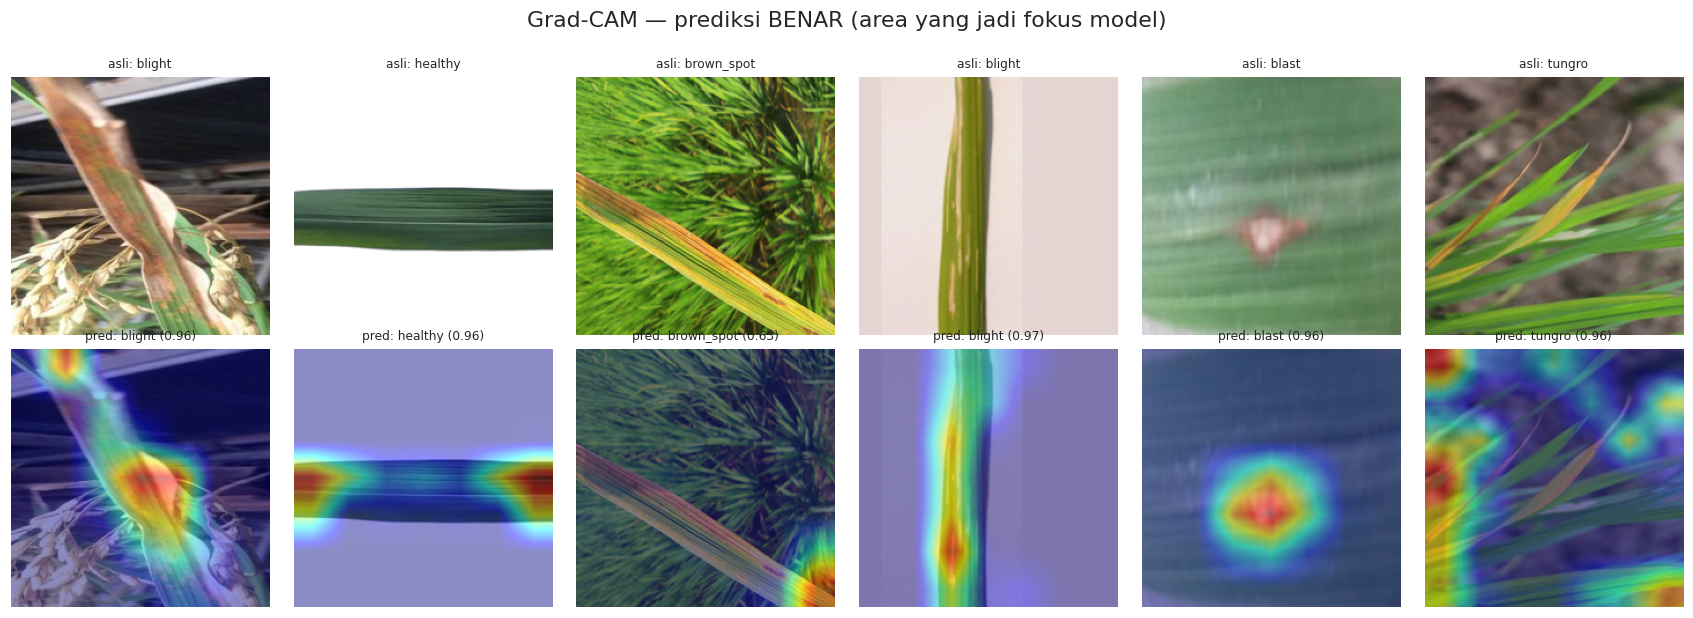

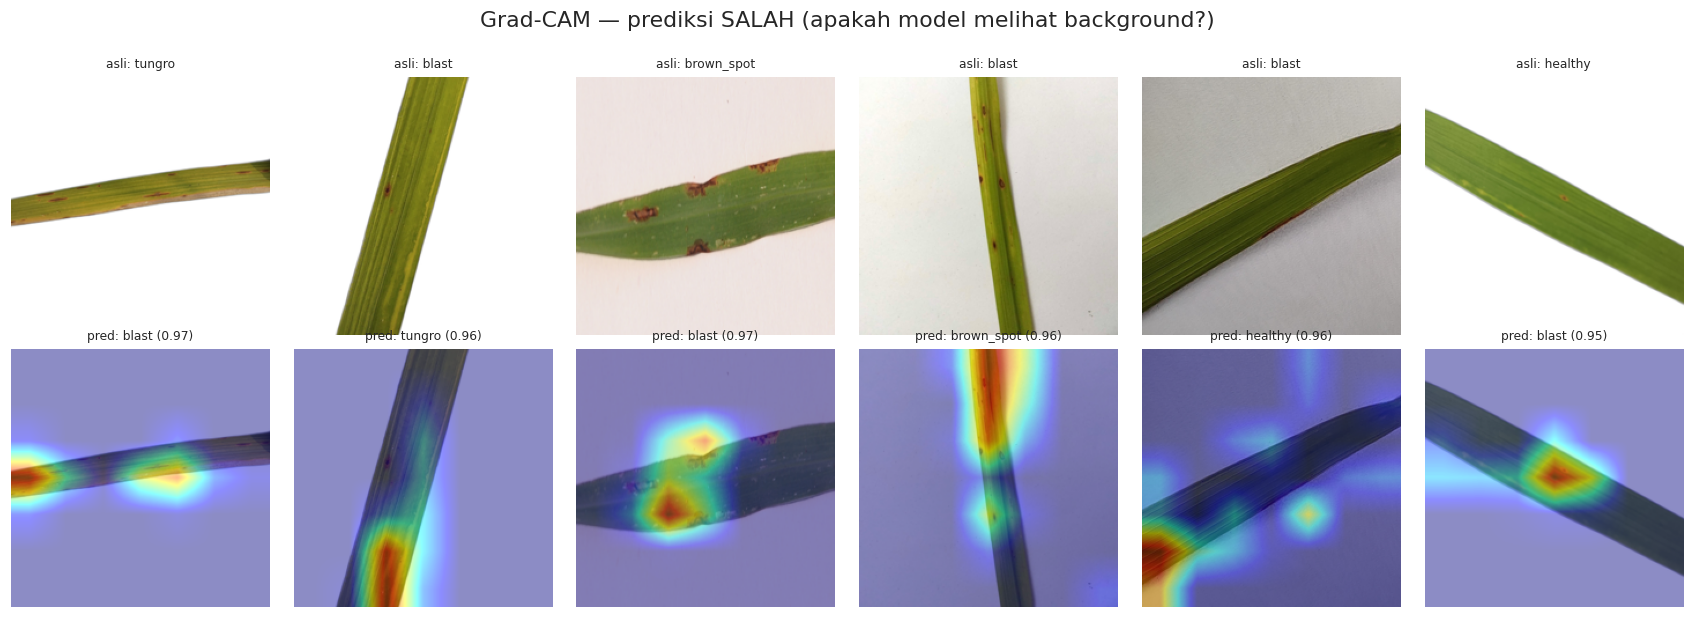

In [30]:
# Grad-CAM, implementasi manual dengan hook,
def get_cam_layer(m):
    if hasattr(m, "stages"):   return m.stages[-1]
    if hasattr(m, "blocks"):   return m.blocks[-1]
    raise ValueError("Tentukan target layer secara manual untuk arsitektur ini.")

def grad_cam(model, x, class_idx=None):
    model.eval()
    store = {}
    layer = get_cam_layer(model)
    h = layer.register_forward_hook(lambda m, i, o: store.__setitem__("act", o))
    try:
        x = x.to(DEVICE).requires_grad_(False)
        logits = model(x)
        if class_idx is None:
            class_idx = logits.argmax(1)
        score = logits.gather(1, class_idx.view(-1, 1)).sum()
        act = store["act"]
        grads = torch.autograd.grad(score, act)[0]  
        weights = grads.mean(dim=(2, 3), keepdim=True)  
        cam = F.relu((weights * act).sum(1)) 
        cam = cam - cam.amin(dim=(1, 2), keepdim=True)
        cam = cam / (cam.amax(dim=(1, 2), keepdim=True) + 1e-8)
        return cam.detach().cpu().numpy(), class_idx.detach().cpu().numpy(), torch.softmax(logits, 1).detach().cpu().numpy()
    finally:
        h.remove()


def show_gradcam(rows, title, fname):
    n = len(rows)
    if n == 0:
        print("Tidak ada gambar untuk ditampilkan."); return
    fig, axes = plt.subplots(2, n, figsize=(2.6 * n, 5.6))
    axes = np.atleast_2d(axes)
    for c, (_, r) in enumerate(rows.iterrows()):
        pil = Image.open(r["path"]).convert("RGB")
        x = eval_tf(pil).unsqueeze(0)
        cam, cls, pr = grad_cam(model, x)
        base = np.asarray(pil.resize((IMG, IMG)))
        heat = cv2.applyColorMap(np.uint8(255 * cv2.resize(cam[0], (IMG, IMG))), cv2.COLORMAP_JET)[:, :, ::-1]
        overlay = np.uint8(0.55 * base + 0.45 * heat)
        axes[0, c].imshow(base); axes[0, c].set_title(f"asli: {r['y_true']}", fontsize=8)
        axes[1, c].imshow(overlay); axes[1, c].set_title(f"pred: {CLASSES[int(cls[0])]} ({pr[0].max():.2f})", fontsize=8)
        axes[0, c].axis("off"); axes[1, c].axis("off")
    plt.suptitle(title, y=1.0)
    plt.tight_layout(); plt.savefig(OUT / f"reports/figures/{fname}", bbox_inches="tight"); plt.show()


correct_rows = test_eval[test_eval["correct"]].sample(min(6, int(test_eval["correct"].sum())), random_state=CONFIG["SEED"])
show_gradcam(correct_rows, "Grad-CAM — prediksi BENAR (area yang jadi fokus model)", "11_gradcam_correct.png")
if len(wrong):
    show_gradcam(wrong.head(min(6, len(wrong))), "Grad-CAM — prediksi SALAH (apakah model melihat background?)", "12_gradcam_wrong.png")

In [31]:
# Iterative Improvement saran otomatis berdasarkan hasil aktual
acc, mf1 = metrics["accuracy"], metrics["macro_f1"]
per_class_f1 = {CLASSES[i]: float(f1_score(y_true == i, y_pred == i, zero_division=0)) for i in range(NUM_CLASSES)}
weakest = min(per_class_f1, key=per_class_f1.get)

print("F1 per kelas:", {k: round(v, 3) for k, v in per_class_f1.items()})
print(f"Kelas terlemah: {weakest} (F1 {per_class_f1[weakest]:.3f})\n")

F1 per kelas: {'blast': 0.961, 'blight': 0.995, 'brown_spot': 0.978, 'healthy': 0.938, 'scald': 0.96, 'tungro': 0.942}
Kelas terlemah: healthy (F1 0.938)



## 6. Export Model

In [32]:
DEPLOY = OUT / "deploy"
DEPLOY.mkdir(parents=True, exist_ok=True)

# Model bersih untuk inference: tanpa drop_path, di CPU, mode eval
export_model = timm.create_model(CONFIG["MODEL_NAME"], pretrained=False, num_classes=NUM_CLASSES, drop_path_rate=0.0)
export_model.load_state_dict(ckpt["state_dict"])
export_model.eval().cpu()


class DeployWrapper(nn.Module):
    # Input : (B,3,H,W) float32 RGB dengan nilai 0..1
    # Output: (B,num_classes) probabilitas (softmax sudah di dalam graph)
    def __init__(self, model, mean, std):
        super().__init__()
        self.model = model
        self.register_buffer("mean", torch.tensor(mean).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor(std).view(1, 3, 1, 1))
    def forward(self, x):
        return torch.softmax(self.model((x - self.mean) / self.std), dim=1)


wrapped = DeployWrapper(export_model, MEAN, STD).eval()
dummy = torch.randn(1, 3, IMG, IMG)

# state_dict PyTorch
torch.save({"state_dict": export_model.state_dict(), "model_name": CONFIG["MODEL_NAME"],
            "classes": CLASSES, "img_size": IMG, "mean": MEAN, "std": STD,
            "test_metrics": metrics}, DEPLOY / "model_state_dict.pth")

# TorchScript
with torch.no_grad():
    ts = torch.jit.trace(export_model, dummy)
    ts = torch.jit.freeze(ts.eval())
ts.save(str(DEPLOY / "model_torchscript.pt"))
with torch.no_grad():
    diff = (ts(dummy) - export_model(dummy)).abs().max().item()
print(f"TorchScript OK | selisih maks vs PyTorch: {diff:.2e}")

TorchScript OK | selisih maks vs PyTorch: 0.00e+00


In [33]:
# Export ONNX
import subprocess

onnx_backend = DEPLOY / "model.onnx"        # input ternormalisasi -> logits
onnx_web     = DEPLOY / "model_web.onnx"    # input 0..1 -> probabilitas


def _ensure_onnxscript():
    try:
        import onnxscript
        return True
    except ImportError:
        print("   menginstal onnxscript ...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "onnxscript"])
        try:
            import onnxscript
            return True
        except ImportError:
            return False


def export_onnx(module, path, out_name):
    kwargs = dict(input_names=["input"], output_names=[out_name],
                  dynamic_axes={"input": {0: "batch"}, out_name: {0: "batch"}},
                  opset_version=17, do_constant_folding=True)
    try:
        torch.onnx.export(module, dummy, str(path), dynamo=False, **kwargs)
        print(f"{path.name}: OK (exporter TorchScript, dynamo=False)")
        return path
    except TypeError:
        torch.onnx.export(module, dummy, str(path), **kwargs)
        print(f"{path.name}: OK (exporter legacy)")
        return path
    except Exception as e:
        print(f"{path.name}: exporter lama gagal ({type(e).__name__}), beralih ke exporter dynamo ...")

    assert _ensure_onnxscript(), "onnxscript gagal dipasang. Aktifkan Internet di Settings Kaggle lalu ulangi."
    torch.onnx.export(module, (dummy,), str(path), dynamo=True, **kwargs)
    print(f"{path.name}: OK (exporter dynamo)")
    return path


export_onnx(export_model, onnx_backend, "logits")
export_onnx(wrapped,      onnx_web,     "probs")

import onnx, onnxruntime as ort

IO_NAMES = {}
for p in [onnx_backend, onnx_web]:
    m = onnx.load(str(p))
    onnx.checker.check_model(m)
    ins  = [i.name for i in m.graph.input]
    outs = [o.name for o in m.graph.output]
    IO_NAMES[p.name] = {"input": ins[0], "output": outs[0]}
    print(f"{p.name:22s} valid | {p.stat().st_size/1e6:6.1f} MB | input={ins} output={outs}")

sess = ort.InferenceSession(str(onnx_web), providers=["CPUExecutionProvider"])
in_name = sess.get_inputs()[0].name
x_np = dummy.numpy().astype(np.float32).clip(0, 1)
onnx_out = sess.run(None, {in_name: x_np})[0]
with torch.no_grad():
    torch_out = wrapped(torch.from_numpy(x_np)).numpy()
print(f"\nSelisih maks ONNX vs PyTorch: {np.abs(onnx_out - torch_out).max():.2e} (harus < 1e-4)")

model.onnx: OK (exporter TorchScript, dynamo=False)
model_web.onnx: OK (exporter TorchScript, dynamo=False)
model.onnx             valid |  111.6 MB | input=['input'] output=['logits']
model_web.onnx         valid |  111.6 MB | input=['input'] output=['probs']

Selisih maks ONNX vs PyTorch: 4.77e-07 (harus < 1e-4)


In [34]:
# Kompresi model untuk deployment (INT8 & FP16)
onnx_int8 = DEPLOY / "model_web_int8.onnx"
onnx_fp16 = DEPLOY / "model_web_fp16.onnx"

try:
    from onnxruntime.quantization import quantize_dynamic, QuantType
    quantize_dynamic(str(onnx_web), str(onnx_int8), weight_type=QuantType.QUInt8)
    print(f"INT8 dibuat: {onnx_int8.stat().st_size/1e6:.1f} MB "
          f"({onnx_web.stat().st_size/onnx_int8.stat().st_size:.1f}x lebih kecil)")
except Exception as e:
    print("Kuantisasi INT8 gagal (opsional, boleh dilewati):", str(e)[:150])

try:
    from onnxconverter_common import float16
    onnx.save(float16.convert_float_to_float16(onnx.load(str(onnx_web))), str(onnx_fp16))
    print(f"FP16 dibuat: {onnx_fp16.stat().st_size/1e6:.1f} MB")
except Exception as e:
    print("Konversi FP16 dilewati:", str(e)[:120])

# Bandingkan akurasi test versi terkompresi vs fp32
def onnx_eval_subset(path, n=200):
    if not Path(path).exists(): return None
    s = ort.InferenceSession(str(path), providers=["CPUExecutionProvider"])
    inp = s.get_inputs()[0]
    dt = np.float16 if "float16" in inp.type else np.float32
    sub = test_eval.sample(min(n, len(test_eval)), random_state=CONFIG["SEED"])
    ok, lat = 0, []
    for _, r in sub.iterrows():
        img = Image.open(r["path"]).convert("RGB").resize((int(IMG*1.15), int(IMG*1.15)))
        left = (img.width - IMG)//2; top = (img.height - IMG)//2
        arr = np.asarray(img.crop((left, top, left+IMG, top+IMG)), dtype=np.float32)/255.0
        arr = np.transpose(arr, (2,0,1))[None].astype(dt)
        t0 = time.time(); p = s.run(None, {inp.name: arr})[0]; lat.append((time.time()-t0)*1000)
        ok += int(CLASSES[int(np.argmax(p))] == r["y_true"])
    return {"accuracy_subset": round(ok/len(sub), 4), "latency_ms_cpu": round(float(np.mean(lat)), 1)}

for name, p in [("fp32", onnx_web), ("int8", onnx_int8), ("fp16", onnx_fp16)]:
    res = onnx_eval_subset(p)
    if res: print(f"{name:5s} -> {res}")

INT8 dibuat: 28.5 MB (3.9x lebih kecil)
FP16 dibuat: 55.9 MB
fp32  -> {'accuracy_subset': 0.97, 'latency_ms_cpu': 80.6}
int8  -> {'accuracy_subset': 0.97, 'latency_ms_cpu': 191.3}
fp16  -> {'accuracy_subset': 0.97, 'latency_ms_cpu': 124.9}


In [35]:
# Artefak pendukung: label kelas dan config preprocessing
labels = {"classes": CLASSES,
          "idx_to_label": {str(i): c for i, c in enumerate(CLASSES)},
          "label_to_idx": {c: i for i, c in enumerate(CLASSES)},
          "display_name": {"blast": "Blast (Blas)", "blight": "Bacterial Leaf Blight (Hawar Daun Bakteri)",
                           "brown_spot": "Brown Spot (Bercak Coklat)", "healthy": "Sehat",
                           "scald": "Leaf Scald (Hangus Daun)", "tungro": "Tungro"}}
json.dump(labels, open(DEPLOY / "labels.json", "w"), indent=2, ensure_ascii=False)

preprocess_config = {
    "model_name": CONFIG["MODEL_NAME"],
    "input_size": [3, IMG, IMG],
    "input_layout": "NCHW",
    "color_space": "RGB",
    "resize_shorter_side_to": int(IMG * 1.15),
    "center_crop": IMG,
    "rescale": "bagi 255 -> rentang 0..1",
    "normalize": {"mean": MEAN, "std": STD,
                  "catatan": "model_web.onnx SUDAH menormalisasi di dalam graph; JANGAN normalisasi lagi. model.onnx BUTUH input ternormalisasi."},
    "output": {"model.onnx": "logits (perlu softmax)", "model_web.onnx": "probabilitas (softmax sudah di dalam)"},
    "io_names": globals().get("IO_NAMES", {}),
    "confidence_threshold": 0.80,
    "catatan_threshold": "Bila confidence < 0.80, kembalikan status 'uncertain' dan minta pengguna memotret ulang.",
    "test_metrics": metrics,
}
json.dump(preprocess_config, open(DEPLOY / "preprocess_config.json", "w"), indent=2, ensure_ascii=False)
print("Artefak pendukung tersimpan:", [p.name for p in DEPLOY.glob("*.json")])

Artefak pendukung tersimpan: ['preprocess_config.json', 'labels.json']


In [36]:
# Kode inference standalone untuk tim Fullstack
inference_code = '''
# inference.py - contoh inference standalone HealthyRice AI
# Output: klasifikasi + confidence saja. Pemetaan label -> rekomendasi penanganan
# dilakukan di sisi aplikasi web, bukan di sini.
# Dua mode: ONNX Runtime (disarankan untuk produksi) atau PyTorch TorchScript.
#   pip install onnxruntime pillow numpy
#   python inference.py --image daun.jpg

import json, argparse
from pathlib import Path
import numpy as np
from PIL import Image

BASE = Path(__file__).parent
CFG = json.load(open(BASE / "preprocess_config.json"))
LABELS = json.load(open(BASE / "labels.json"))
CLASSES = LABELS["classes"]
IMG = CFG["center_crop"]
THRESHOLD = CFG["confidence_threshold"]


def preprocess(image, normalize=False):
    # image: path / PIL.Image / bytes. Urutan WAJIB sama dengan training:
    # resize sisi terpendek -> center crop -> /255 -> (opsional) normalisasi -> NCHW
    if not isinstance(image, Image.Image):
        image = Image.open(image)
    img = image.convert("RGB")
    short = CFG["resize_shorter_side_to"]
    w, h = img.size
    scale = short / min(w, h)
    img = img.resize((round(w * scale), round(h * scale)), Image.BILINEAR)
    left, top = (img.width - IMG) // 2, (img.height - IMG) // 2
    img = img.crop((left, top, left + IMG, top + IMG))
    arr = np.asarray(img, dtype=np.float32) / 255.0
    if normalize:
        arr = (arr - np.array(CFG["normalize"]["mean"], np.float32)) / np.array(CFG["normalize"]["std"], np.float32)
    return np.transpose(arr, (2, 0, 1))[None]        # (1,3,H,W)


class RiceDiseaseONNX:
    # model_web.onnx: normalisasi + softmax sudah ada di dalam graph
    def __init__(self, model_path=BASE / "model_web.onnx"):
        import onnxruntime as ort
        so = ort.SessionOptions()
        so.intra_op_num_threads = 2
        self.sess = ort.InferenceSession(str(model_path), so, providers=["CPUExecutionProvider"])
        self.input_name = self.sess.get_inputs()[0].name

    def predict(self, image, top_k=3):
        x = preprocess(image, normalize=False)
        probs = self.sess.run(None, {self.input_name: x.astype(np.float32)})[0][0]
        order = np.argsort(-probs)[:top_k]
        top = [{"label": CLASSES[i],
                "display_name": LABELS["display_name"][CLASSES[i]],
                "confidence": round(float(probs[i]), 4)} for i in order]
        best = top[0]
        uncertain = best["confidence"] < THRESHOLD
        return {
            "prediction": best["label"],
            "display_name": best["display_name"],
            "confidence": best["confidence"],
            "is_uncertain": uncertain,
            "message": ("Model kurang yakin. Mohon foto ulang daun dari jarak dekat dengan pencahayaan cukup."
                        if uncertain else "Deteksi berhasil."),
            "top_k": top,
        }


class RiceDiseaseTorch:
    # Alternatif TorchScript (butuh input TERNORMALISASI dan softmax manual)
    def __init__(self, model_path=BASE / "model_torchscript.pt"):
        import torch
        self.torch = torch
        self.model = torch.jit.load(str(model_path), map_location="cpu").eval()

    def predict(self, image, top_k=3):
        x = self.torch.from_numpy(preprocess(image, normalize=True).astype(np.float32))
        with self.torch.no_grad():
            probs = self.torch.softmax(self.model(x), 1)[0].numpy()
        order = np.argsort(-probs)[:top_k]
        return {"prediction": CLASSES[order[0]], "confidence": round(float(probs[order[0]]), 4),
                "top_k": [{"label": CLASSES[i], "confidence": round(float(probs[i]), 4)} for i in order]}


if __name__ == "__main__":
    ap = argparse.ArgumentParser()
    ap.add_argument("--image", required=True)
    ap.add_argument("--backend", default="onnx", choices=["onnx", "torch"])
    a = ap.parse_args()
    clf = RiceDiseaseONNX() if a.backend == "onnx" else RiceDiseaseTorch()
    print(json.dumps(clf.predict(a.image), indent=2, ensure_ascii=False))
'''

(DEPLOY / "inference.py").write_text(inference_code.strip() + "\n")
(DEPLOY / "requirements.txt").write_text("onnxruntime>=1.17.0\npillow>=10.0.0\nnumpy>=1.24.0\n")
print("inference.py & requirements.txt tersimpan.")

# Uji langsung kode inference tersebut pada gambar test
sys.path.insert(0, str(DEPLOY))
import importlib, inference as inf_mod
importlib.reload(inf_mod)

clf = inf_mod.RiceDiseaseONNX(DEPLOY / "model_web.onnx")
sample = test_eval.sample(3, random_state=1)
for _, r in sample.iterrows():
    out = clf.predict(r["path"])
    print(f"\nFile   : {Path(r['path']).name}  (label asli: {r['y_true']})")
    print(f"Prediksi: {out['prediction']} | confidence {out['confidence']:.3f} | uncertain={out['is_uncertain']}")
    print(f"Top-3  : {[(t['label'], t['confidence']) for t in out['top_k']]}")

t0 = time.time()
for _ in range(10):
    clf.predict(sample.iloc[0]["path"])
print(f"\nLatensi rata-rata end-to-end (CPU, termasuk preprocessing): {(time.time()-t0)/10*1000:.1f} ms/gambar")

inference.py & requirements.txt tersimpan.

File   : IMG_20231018_143546.jpg  (label asli: blast)
Prediksi: blast | confidence 0.959 | uncertain=False
Top-3  : [('blast', 0.9588), ('brown_spot', 0.0092), ('blight', 0.0091)]

File   : TUNGRO4_119.JPG  (label asli: tungro)
Prediksi: tungro | confidence 0.960 | uncertain=False
Top-3  : [('tungro', 0.9602), ('scald', 0.0085), ('blight', 0.0079)]

File   : RB_625.jpg  (label asli: blast)
Prediksi: blast | confidence 0.974 | uncertain=False
Top-3  : [('blast', 0.9741), ('brown_spot', 0.006), ('tungro', 0.0058)]

Latensi rata-rata end-to-end (CPU, termasuk preprocessing): 105.7 ms/gambar


In [38]:
# Model card
model_card = f'''# HealthyRice AI - Model Card

## Ringkasan
- Arsitektur      : {CONFIG["MODEL_NAME"]} (timm, transfer learning)
- Tugas           : klasifikasi 6 kelas penyakit daun padi
- Kelas           : {", ".join(CLASSES)}
- Input           : RGB {IMG}x{IMG}, NCHW, rentang 0..1 (model_web.onnx) / ternormalisasi (model.onnx)
- Tanggal training: {time.strftime("%Y-%m-%d")}

## Data
- Total gambar setelah cleaning : {len(df)}
- Split (group-aware, stratified): train {len(train_df)} / val {len(val_df)} / test {len(test_df)}
- Anti-leakage: gambar near-duplicate (pHash Hamming <= {CONFIG["PHASH_DUP_THRESHOLD"]}) dikunci dalam group yang sama sehingga tidak tersebar antar split.

## Performa (test set)
| Metrik | Nilai |
|---|---|
| Accuracy | {metrics["accuracy"]:.4f} |
| Macro F1 | {metrics["macro_f1"]:.4f} |
| Macro Precision | {metrics["macro_precision"]:.4f} |
| Macro Recall | {metrics["macro_recall"]:.4f} |

## Keterbatasan
- Dilatih pada dataset publik multi-source, performa pada foto HP di sawah nyata bisa lebih rendah (domain gap).
- Model tidak mengenali kondisi di luar 6 kelas (hama, defisiensi hara, tanaman non-padi) - gunakan confidence threshold {preprocess_config["confidence_threshold"]}.
- Ruang lingkup model hanya klasifikasi gambar (label + confidence). Rekomendasi penanganan dikelola aplikasi web.

## Cara pakai
Lihat `inference.py` dan `preprocess_config.json`.
'''
(DEPLOY / "MODEL_CARD.md").write_text(model_card)

zip_path = OUT / "healthyrice_deploy.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for f in sorted(DEPLOY.glob("*")):
        if f.is_file():
            z.write(f, f.name)

print("=" * 62)
print("ISI FOLDER DEPLOY")
print("=" * 62)
for f in sorted(DEPLOY.glob("*")):
    print(f"  {f.name:28s} {f.stat().st_size/1e6:8.2f} MB")
print(f"\nPaket ZIP: {zip_path} ({zip_path.stat().st_size/1e6:.2f} MB)")
print("\nStruktur output lengkap:")
for p in sorted(OUT.rglob("*")):
    if p.is_file():
        print("  ", p.relative_to(OUT))

ISI FOLDER DEPLOY
  MODEL_CARD.md                    0.00 MB
  __pycache__                      0.00 MB
  inference.py                     0.00 MB
  labels.json                      0.00 MB
  model.onnx                     111.60 MB
  model_state_dict.pth           111.56 MB
  model_torchscript.pt           111.55 MB
  model_web.onnx                 111.61 MB
  model_web_fp16.onnx             55.92 MB
  model_web_int8.onnx             28.48 MB
  preprocess_config.json           0.00 MB
  requirements.txt                 0.00 MB

Paket ZIP: /kaggle/working/artifacts/healthyrice_deploy.zip (484.75 MB)

Struktur output lengkap:
   checkpoints/best_model.pth
   deploy/MODEL_CARD.md
   deploy/__pycache__/inference.cpython-312.pyc
   deploy/inference.py
   deploy/labels.json
   deploy/model.onnx
   deploy/model_state_dict.pth
   deploy/model_torchscript.pt
   deploy/model_web.onnx
   deploy/model_web_fp16.onnx
   deploy/model_web_int8.onnx
   deploy/preprocess_config.json
   deploy/requireme